---
title: "The van Deemter equation: the three terms, the constants they were read off, and what the Gaussian costs"
description: "H = A + B/u + Cu is fitted to twelve points on one page of a 1956 paper. Rebuilding the chain that produced it recovers the film thickness, the particle diffusivity, and one printed equation that cannot be right."
categories: [sec:J, struct:S4, tier:T0, data:tier6, phase:gas-liquid, phase:liquid-solid]
date: 2026-08-09
---

# The van Deemter equation: the three terms, the constants they were read off, and what the Gaussian costs

**Catalog ID:** `J1.10` · **Structures:** `S4` (1-D transient PDE) · **Tier:** T0

Every chromatography textbook prints

$$H = A + \frac{B}{u} + C u,$$

attributes it to van Deemter, Zuiderweg and Klinkenberg (1956), and moves on.
The 1956 paper does not start there. It starts from a two-phase material
balance, reduces it to a Gaussian, and only then — on page 286, from twelve
measured points — writes down three numbers. This page rebuilds that chain,
end to end, and reports what each step actually supports.

## Background

A band injected into a chromatographic column comes out wider than it went in.
The plate theory of Martin and Synge describes *how much* wider with one
empirical number per column, the height equivalent to a theoretical plate, and
says nothing about where that number comes from. The rate theory of Lapidus and
Amundson describes the mechanisms — longitudinal diffusion, finite mass
transfer — but its solution is an integral over a Bessel function, which in
1956 was not something you evaluated for a design.

The 1956 paper is the join. Its abstract lists the three causes it treats:

> axial molecular diffusion, axial eddy diffusion, finiteness of transfer
> coefficient

and its contribution is that under conditions it states explicitly, the rate
theory collapses to a Gaussian whose width is *additive* in those three
mechanisms. That additivity is the van Deemter equation. It is why the
familiar $A + B/u + Cu$ has one term per mechanism and no cross terms.

Three things about the paper are easy to miss and matter here.

1. **Two experiments, not one.** Sections apply the theory to *ion exclusion*
   (Simpson and Wheaton's data, restated in Table 2, reduced to plate heights in
   Table 3) and to *gas–liquid partition chromatography* (the authors' own
   Table 4). Only the second produces the famous three-term formula; the first
   produces the particle diffusivity and the packing factor $\lambda$ that the
   second then reuses.
2. **The constants were read off graphs.** Eq. (54) is a description of
   Fig. 11, and the paper says so — "the values of the constants in (54) are
   highly uncertain, owing to the relatively small number of experimental data
   that were available".
3. **The paper criticises its own fit.** The eddy term "should obviously have
   the same value for both components. The formulae (54) do not agree with
   theory in this respect" — 0.3 mm for *n*-butane against 0.8 mm for
   iso-butane.

## The published model

**The balance (eqs. 29 and 30, p. 278),** per unit cross-sectional area, with
$F_I$ and $F_{II}$ the fractional volumes of the mobile and immobile phases,
$K = (c_I/c_{II})_{\text{equilibrium}}$ the distribution factor, $\alpha$ the
mass transfer coefficient per unit volume of packing, and $u$ the **interstitial**
velocity (the paper's own List of Symbols, p. 288):

$$F_I\frac{\partial c_I}{\partial t}
  = F_I D\frac{\partial^2 c_I}{\partial z^2}
  - F_I u\frac{\partial c_I}{\partial z}
  + \alpha\,(K c_{II} - c_I),
\qquad
F_{II}\frac{\partial c_{II}}{\partial t} = \alpha\,(c_I - K c_{II}).$$

**The Gaussian (eqs. 33 and 34, p. 279).** For $z$ much larger than both
$2D/u$ and $F_I u/\alpha$, the Lapidus–Amundson solution reduces to

$$\frac{c_I}{c_0} = \frac{\beta t_0}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}}
   \exp\!\left[-\frac{(z/u-\beta t)^2}{2(\sigma_1^2+\sigma_2^2)}\right],
\qquad
\frac{1}{\beta} = 1 + \frac{F_{II}}{F_I K},\quad
\sigma_1^2 = \frac{2Dz}{u^3},\quad
\sigma_2^2 = 2\beta^2\frac{F_{II}^2 z}{\alpha F_I K^2 u}.$$

**The plate height (eq. 38, p. 279).** Comparing that Gaussian with the plate
theory's gives

$$H = 2\frac{D}{u} + 2\,\frac{u F_I/\alpha}{\left(1 + K\dfrac{F_I}{F_{II}}\right)^2}.$$

**The three terms (eqs. 47, 48 and 53, pp. 282–283).** Writing the longitudinal
diffusivity as $D = \gamma D_I + \lambda u d_p$ and the transfer resistance as
diffusion into a liquid film of thickness $d_f$ (eqs. 50–52):

$$H = \underbrace{2\gamma\frac{D_I}{u}}_{B/u}
    + \underbrace{2\lambda d_p}_{A}
    + \underbrace{\frac{8}{\pi^2}\,
      \frac{K F_I d_f^2}{\left(1+K\frac{F_I}{F_{II}}\right)^2 D_{II} F_{II}}\;u}_{Cu}.$$

That is the van Deemter equation. Each of the three constants is a *product of
printed quantities*, which is what makes the rest of this page possible: the
paper inverts the relation to obtain $\gamma D_I$, $\lambda$ and $d_f$, and each
inversion can be redone.

**The particle form (eq. 49, p. 282)**, used for the ion-exclusion column, where
the resistance is inside a solid particle rather than a film:

$$\frac{H}{d_p} = 2\gamma\frac{D_I}{u d_p} + 2\lambda + C\,\frac{u d_p}{D_I},
\qquad
C = \frac{\dfrac{F_I^{2}}{75(1-F_I)^{2}}
        + \dfrac{F_I K D_I}{2\pi^{2}(1-F_I)D_{II}}}
        {\left(1+K\dfrac{F_I}{F_{II}}\right)^{2}}.$$

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import eye_array, bmat
from scipy.sparse.linalg import splu
from scipy.special import erf, erfinv
from scipy.optimize import brentq
from pymrm import (construct_grad, construct_div, construct_convflux_upwind,
                   interp_cntr_to_stagg_tvd, vanleer)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "J1.10-van-deemter-plate-height"
np.random.seed(0)                       # nothing here is stochastic; pinned anyway
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
SQ2 = np.sqrt(2.0)

# Deviations are reported ONE way everywhere on this page:
#     dev = (computed - printed) / printed
def dev(computed, printed):
    return np.asarray(computed, float) / np.asarray(printed, float) - 1.0

## Parameters and assumptions

**What is printed, and what is not.** The gas–liquid columns are described
completely enough to evaluate eq. (53): both are 1.80 m long and 6 mm in
internal diameter, the Celite carrier averages 30 µm and the Sterchamol 240 µm,
$K F_I/F_{II}$ is given for all three column/solute combinations, and $D_{II}$
in the oil film is estimated from its viscosity as $0.3\times10^{-10}$ m² s⁻¹.
What is **not** printed for those columns is $F_I$ itself. That matters, and the
page returns to it.

The ion-exclusion column is described the other way round: $F_I = F_{II} = 0.4$
and $K = 1.3$ are printed (p. 282), but its **length is not**, anywhere. The
length this page uses is recovered from Table 3's own columns - the value is
computed and printed in *Table 3 checked against itself*, below - and is
labelled an inference every time it appears.

**Assumptions carried from the paper, unchanged.** Linear isotherm; constant
$F_I$, $F_{II}$ and $u$; a single solute at low concentration; eddy diffusivity
$E = \lambda u d_p$ (eq. 47); gas-phase transfer resistance neglected in the
gas–liquid case, which the paper checks afterwards with its eq. (56).

**One convention this page does not adopt silently.** The List of Symbols
defines $u$ as the interstitial velocity and eqs. (29)/(30) use it that way, but
Tables 2, 3 and 4 and Figs. 11–14 are all headed *superficial* velocity. Fig. 9
converts (its abscissa is $u F_I d_p$); the gas–liquid section does not appear
to. The page carries both readings explicitly wherever the difference changes a
number.

## The data

Five files, all transcription, no digitisation. The paper has **four** printed
tables, not two — a point worth stating because the case notes for this build
said two, and the ones that carry the plate height are Tables 3 and 4.

| file | what it is | who measured it |
|---|---|---|
| `…table1-feed-volume` | Table 1, p. 277: elution-curve width and height against feed volume, 24 rows | the authors |
| `…table2-simpson-wheaton` | Table 2, p. 280: ion-exclusion elution curves, 13 rows | **Simpson & Wheaton**, restated |
| `…table3-hetp` | Table 3, p. 281: plate heights derived from Table 2, 10 rows (one printed twice) | derived by the authors |
| `…table4-glc-hetp` | Table 4, p. 286: plate height against gas velocity, two columns, 24 rows | the authors |
| `…printed-scalars` | 56 scalars from pp. 277–287, tagged `input` or `result` | — |

**How they were read.** Every numeric cell was read on a 2× digit-scale crop of
a 300 ppi render — the scan's native resolution, checked with `pdfimages -list`.
The text layer was used for nothing numeric: it misreads the journal *volume* in
the document's first line, printing `Vol 6` where the page prints `Vol. 5`. The
1956 Pergamon face sets the decimal point as a raised mid-dot which the scan
drops to a space, so a cell reading `0 163 1100 0 27 0 30` is
`0` `163` `1100` `0.27` `0.30`.

**Five readings were settled by arithmetic constraints the tables impose on
themselves, not by pixel shape**, and the sidecars name the constraint for each:

* Table 2's velocity column is a **doubling series** — 0.046, 0.091, 0.182,
  0.365, 0.73, each twice the last to within the printed rounding. That fixes
  `0 365` as 0.365 and not 0.865.
* The 23 ml base width on that same row is the only reading consistent with the
  125–156 plates Table 3 prints for it.
* Table 3's `11 -18` could be 11–18 or 1.1–1.8. $H$ divided by $H/d_p$ is the
  particle diameter, and it must agree with the mesh: 0.56/11 = 0.051 mm is a
  200–400 mesh particle, 0.56/1.1 = 0.51 mm is a 30–40 mesh one. The row is
  200–400 mesh.
* The same test fixes `13 -14` and `16 -20` as integer pairs.
* Table 3's `0 56- 0 93` keeps its decimal points where $nH$ — the column
  length, which must be the same in every row — puts them.

**Figs. 11 and 13 were consulted for three readings, spanning five cells of
Table 4**: the Celite `3 4`/`3 5` pair, the Sterchamol `3 2`/`3 3` pair, and
`31` against `81` (the 1956 face sets `3` with a nearly flat top). No point was
taken off either figure; what was used is that neither carries a point between
$u = 5$ and 15 mm s⁻¹, and that Fig. 13's rightmost point sits at $u \approx 31$
on an axis stopping just past it. **All three are also forced from inside
Table 4 alone** — the stronger statement, and the one checked in code below. The
check is run on the cells *not* in dispute, because testing whether the
transcribed column ascends would assume the reading it is offered as evidence
for: the undisputed cells of each block ascend, and of the four candidate
readings of the disputed pair only the printed one can be inserted at its two
positions without breaking that order. Position does **not** decide the third
cell — 81 is larger than everything above it either way — and the page does not
claim it does; eq. (55), which the authors fitted to these very rows, overshoots
the printed plate height by more than a factor two at $u = 81$ while landing
within a few per cent of it at $u = 31$.

Two of the 56 scalars, $n = 240$ and $n = 277$, are numbers **printed as curve
labels** on Fig. 8 (p. 280). They are read as printed text, not as point
coordinates, and are used in exactly one place: to identify which of Table 3's
two printed endpoints came from which of the paper's two routes.

**Simpson & Wheaton's paper is not on disk and was not consulted.** Table 2 is
van Deemter et al.'s restatement of it. Nothing on this page claims anything
about the original.

In [3]:
T1 = load_data("vandeemter-1956-table1-feed-volume.csv", page=PAGE)
T2 = load_data("vandeemter-1956-table2-simpson-wheaton.csv", page=PAGE)
T3 = load_data("vandeemter-1956-table3-hetp.csv", page=PAGE)
T4 = load_data("vandeemter-1956-table4-glc-hetp.csv", page=PAGE)
SC = load_data("vandeemter-1956-printed-scalars.csv", page=PAGE)
P = dict(zip(SC.quantity, SC.value))                 # every printed scalar, by key

print(cite_data(load_meta("vandeemter-1956-table3-hetp.csv", page=PAGE)))
print(f"\nTable 1 {len(T1):3d} rows   Table 2 {len(T2):3d} rows   "
      f"Table 3 {len(T3):3d} rows   Table 4 {len(T4):3d} rows")
print(f"printed scalars: {len(SC)} ({(SC.kind=='input').sum()} inputs, "
      f"{(SC.kind=='result').sum()} stated results), journal pp. "
      f"{int(SC.page.min())}-{int(SC.page.max())}")

# The Celite sieve analysis printed inside Table 4's carrier column.
sieve = {">40 um": 24.0, "40-20 um": 52.0, "20-10 um": 18.5, "10-6 um": 4.5, "<6 um": 1.0}
print(f"\nCelite sieve analysis as printed sums to {sum(sieve.values()):.1f} %")

# The two constraints INTERNAL to Table 4 that settle its three ambiguous
# readings without Figs. 11/13 (see the text above).
#
# The monotonicity test must be run on the cells NOT in dispute, otherwise it is
# circular: asking whether the transcribed column ascends, when the transcription
# already contains 3.4/3.5, can only ever answer True. So: establish the order on
# the undisputed cells, then insert each candidate reading at its printed
# position and see which candidates survive.
DISPUTED = {"celite": (3.4, 3.5), "sterchamol": (3.2, 3.3)}
ALTS = {"celite":     [(8.4, 8.5), (3.4, 8.5), (8.4, 3.5)],   # the leading 3 read
        "sterchamol": [(8.2, 8.3), (3.2, 8.3), (8.2, 3.3)]}   # as an 8, in either cell
ascends = lambda v: bool(np.all(np.diff(np.asarray(v, float)) >= 0))

print("\nTable 4's velocity column, tested on the cells that are NOT in dispute:")
BLOCKS = {}
for c, g in T4.groupby("solid_carrier"):
    v = g.superficial_velocity_mm_s.to_numpy(float)
    pos = [int(np.flatnonzero(np.isclose(v, x))[0]) for x in DISPUTED[c]]
    keep = np.delete(v, pos)
    BLOCKS[c] = (v, pos, keep)
    print(f"   {c:<11s}{len(keep):2d} undisputed cells "
          f"[{', '.join(f'{x:g}' for x in keep)}]  ascending: {ascends(keep)}")

POS_SETTLES = True
for c, (v, pos, keep) in BLOCKS.items():
    print(f"   {c}: inserting each candidate reading at its two printed positions")
    for cand in [DISPUTED[c]] + ALTS[c]:
        w = v.copy(); w[pos[0]], w[pos[1]] = cand
        ok = ascends(w)
        POS_SETTLES &= (ok == (cand == DISPUTED[c]))
        print(f"      {cand[0]:>4g} / {cand[1]:<4g}  whole column ascending: {ok}"
              f"{'   <- the reading used' if cand == DISPUTED[c] else ''}")
print(f"   -> position alone settles both pairs, and only the printed reading "
      f"survives: {POS_SETTLES}")

# The third ambiguous cell is NOT settled by position, and the page does not
# pretend otherwise: 81 is larger than every cell above it either way. Same
# undisputed column as above, with only its last cell varied.
v_31 = BLOCKS["sterchamol"][2]
v_81 = v_31.copy(); v_81[-1] = 81.0
print(f"\n   The last Sterchamol cell: reading it 31 leaves the undisputed column "
      f"ascending ({ascends(v_31)}),")
print(f"      and so does reading it 81 ({ascends(v_81)}) - position does NOT decide "
      f"this one.")
h55 = lambda u: P["eq55_B_sterchamol"] / u + P["eq55_C_sterchamol"] * u
h31 = float(T4[(T4.solid_carrier == "sterchamol")
               & (T4.superficial_velocity_mm_s == 31)].hetp_n_butane_mm.iloc[0])
print(f"   eq (55), fitted by the authors to these rows, gives {h55(31):.2f} mm at "
      f"u = 31 against the printed {h31} mm ({dev(h55(31), h31):+.0%}),")
print(f"      and {h55(81):.2f} mm at u = 81 ({dev(h55(81), h31):+.0%}) - which excludes "
      f"the 81 reading from inside the table.")

van Deemter, J. J.; Zuiderweg, F. J.; Klinkenberg, A. (1956) — Chemical Engineering Science 5(6) 271-289 — doi:10.1016/0009-2509(56)80003-1 — table

Table 1  24 rows   Table 2  13 rows   Table 3  10 rows   Table 4  24 rows
printed scalars: 56 (35 inputs, 21 stated results), journal pp. 278-287

Celite sieve analysis as printed sums to 100.0 %

Table 4's velocity column, tested on the cells that are NOT in dispute:
   celite     10 undisputed cells [1.7, 2, 4.8, 5, 15, 15, 15, 15, 23, 23]  ascending: True
   sterchamol 10 undisputed cells [1.8, 2, 5, 5, 5, 17, 17, 17, 17, 31]  ascending: True
   celite: inserting each candidate reading at its two printed positions
       3.4 / 3.5   whole column ascending: True   <- the reading used
       8.4 / 8.5   whole column ascending: False
       3.4 / 8.5   whole column ascending: False
       8.4 / 3.5   whole column ascending: False
   sterchamol: inserting each candidate reading at its two printed positions
       3.2 / 3.3   whole column as

### Table 3 checked against itself, before anything is fitted to it

Table 3 prints $n$, $H$ and $H/d_p$ for the same experiment. Two of those three
are enough to determine the third, so the table constrains itself twice over:

* $nH$ is the column length, and must be the **same in every row** — even though
  no column length is printed anywhere in the paper;
* $H \div (H/d_p)$ is the particle diameter, and must be the **same for a given
  mesh**, whatever the flow rate.

Neither identity is used to build anything below. They are here because they are
the only check available on a transcription of a table whose every cell is a
range.

In [4]:
# Both printed ranges in a row run in OPPOSITE senses: the larger plate number
# pairs with the smaller plate height. That is what makes the product sharp.
Lhi = T3.n_plates_lo * T3.hetp_hi_mm
Llo = T3.n_plates_hi * T3.hetp_lo_mm
L_all = np.concatenate([Lhi.to_numpy(), Llo.to_numpy()])
L_SW = float(np.mean(L_all))

print("Recovered column length  l = n H   (mm)")
print(f"{'mesh':>8}{'u':>7}{'n_lo*H_hi':>11}{'n_hi*H_lo':>11}")
for (_, r), a, b in zip(T3.iterrows(), Lhi, Llo):
    print(f"{r.particle_mesh:>8}{r.superficial_velocity_mm_s:>7.3f}{a:>11.1f}{b:>11.1f}")
print(f"\n  mean {L_SW:.1f} mm, spread {L_all.min():.0f}-{L_all.max():.0f} mm "
      f"({(L_all.max()/L_all.min()-1)*100:.1f} % wide, against 2-sig-fig rounding "
      f"on H of up to {(0.05/T3.hetp_lo_mm).max()*100:.1f} %)")

dp_row = 0.5*(T3.hetp_lo_mm + T3.hetp_hi_mm) / (0.5*(T3.h_over_dp_lo + T3.h_over_dp_hi))
print("\nRecovered particle diameter  d_p = H / (H/d_p)   (mm)")
for mesh, g in dp_row.groupby(T3.particle_mesh):
    lo, hi = [float(x) for x in mesh.split("-")]
    print(f"  {mesh:>8} mesh : {'  '.join(f'{v:.4f}' for v in g)}"
          f"   (mean {g.mean():.4f}, {len(g)} row(s))")
uniq = ~T3.duplicated(subset=["particle_mesh", "superficial_velocity_mm_s"])
DP_50_100 = float(dp_row[(T3.particle_mesh == "50-100") & uniq].mean())
print(f"\n  50-100 mesh, the only series with a flow sweep: d_p = {DP_50_100:.4f} mm "
      f"(five distinct flow rates, row spread "
      f"{dp_row[(T3.particle_mesh=='50-100') & uniq].min():.4f}-"
      f"{dp_row[(T3.particle_mesh=='50-100') & uniq].max():.4f})")

Recovered column length  l = n H   (mm)
    mesh      u  n_lo*H_hi  n_hi*H_lo
 200-400  0.091      558.0      560.0
  50-100  0.091      552.0      554.0
   50-70  0.091      560.0      549.0
   30-40  0.091      561.0      558.0
   16-20  0.091      560.0      539.0
  50-100  0.046      577.5      555.6
  50-100  0.091      552.0      554.0
  50-100  0.182      566.4      567.0
  50-100  0.365      562.5      561.6
  50-100  0.730      561.6      560.7

  mean 558.5 mm, spread 539-578 mm (7.1 % wide, against 2-sig-fig rounding on H of up to 8.9 %)

Recovered particle diameter  d_p = H / (H/d_p)   (mm)
     16-20 mesh : 1.0000   (mean 1.0000, 1 row(s))
   200-400 mesh : 0.0514   (mean 0.0514, 1 row(s))
     30-40 mesh : 0.5000   (mean 0.5000, 1 row(s))
    50-100 mesh : 0.2161  0.2231  0.2161  0.2185  0.2250  0.2177   (mean 0.2194, 6 row(s))
     50-70 mesh : 0.2484   (mean 0.2484, 1 row(s))

  50-100 mesh, the only series with a flow sweep: d_p = 0.2201 mm (five distinct flow rates, r

## PyMRM implementation

Two things are built here. The first is a **symbolic** reconstruction of the
paper's chain of equations, which needs no solver and is what most of this page
rests on. The second is the **transient two-phase column** of eqs. (29)/(30),
solved with pymrm, which is the only thing on the page that can test eq. (38)
without using eq. (38).

### The column

`Column` assembles the operators once, in `__init__`, and never inside a time
step. Only $c_I$ carries a spatial operator; $c_{II}$ exchanges with it
pointwise, so the two fields are assembled monolithically with `bmat` rather
than through a shared axis — the immobile phase has no flux and no gradient, and
giving it one would be a modelling error dressed as convenience.

The inlet is a Danckwerts condition, written on the **outward** normal
($n = -z$ at the left face, so $\partial c/\partial n = -\partial c/\partial z$):

$$u c_I - D\frac{\partial c_I}{\partial z}\bigg|_{0} = u\,c_{\text{in}}(t)
\;\Longrightarrow\;
D\frac{\partial c_I}{\partial n} + u\,c_I = u\,c_{\text{in}}(t)
\;\Longrightarrow\; a = D,\; b = u,\; d = u\,c_{\text{in}}.$$

Only $d$ varies in time, and the boundary vectors are linear in $d$, so they are
built once for $c_{\text{in}} = 1$ and scaled — the matrices stay constant, which
is the whole point of the convention.

In [5]:
class Column:
    """van Deemter eqs (29)-(30): a linear two-phase chromatographic column.

    Fields are (n_z, 1) per phase - never a bare (n_z,) - and the two phases are
    stacked into one 2 n_z system.  Convection is upwind with an optional van
    Leer deferred correction; time stepping is Crank-Nicolson.
    """

    def __init__(self, u, D, alpha, K, F_I, F_II, L, n_z, limiter=vanleer,
                 nu=0, bc_left=None):
        self.__dict__.update(u=u, D=D, alpha=alpha, K=K, F_I=F_I, F_II=F_II,
                             L=L, n_z=n_z, limiter=limiter)
        self.x_f = np.linspace(0.0, L, n_z + 1)
        self.x_c = 0.5 * (self.x_f[:-1] + self.x_f[1:])
        shape = (n_z, 1)                       # never (n_z,): see AGENTS.md
        # outward normal, so both dicts read   a dc/dn + b c = d
        #   z = 0  Danckwerts inflow  u c - D dc/dz = u c_in  -> a=D, b=u, d=u*1
        #   z = L  zero-gradient outflow                      -> a=1, b=0, d=0
        self.bc = (bc_left or {"a": D, "b": u, "d": u},
                   {"a": 1.0, "b": 0.0, "d": 0.0})
        conv, conv_bc = construct_convflux_upwind(shape, self.x_f, self.x_c,
                                                  self.bc, v=u)
        grad, grad_bc = construct_grad(shape, self.x_f, self.x_c, self.bc)
        div = construct_div(shape, self.x_f, nu=nu)        # nu=0: Cartesian slab
        self.div = div
        T = div @ (conv - D * grad)                        # transport of c_I
        self.bvec = -np.asarray((div @ (conv_bc - D * grad_bc)).todense()).ravel()
        I = eye_array(n_z, format="csc")
        # d/dt [c_I ; c_II] = M [c_I ; c_II] + b(t)
        self.M = bmat([[-T - (alpha / F_I) * I, (alpha * K / F_I) * I],
                       [(alpha / F_II) * I, -(alpha * K / F_II) * I]], format="csc")
        self.v_face = np.full((n_z + 1, 1), u)

    def _corr(self, cI):
        """van Leer deferred correction on the convective flux (0 if limiter None)."""
        if self.limiter is None:
            return np.zeros(self.n_z)
        _, dg = interp_cntr_to_stagg_tvd(cI.reshape(-1, 1), self.x_f, self.x_c,
                                         self.bc, self.v_face,
                                         tvd_limiter=self.limiter)
        return -np.asarray(self.div @ (self.v_face * dg.reshape(-1, 1))).ravel()

    def run(self, t_end, dt, t_sig, stations, sweeps=1, theta=0.5):
        """Gaussian inlet pulse of width t_sig centred at 5 t_sig (so that it is
        smooth, resolved, and negligible at t = 0); record c_I at the stations.
        The two-station reading is independent of the pulse, but a SMOOTH one
        keeps the time quadrature from being O(dt) on a discontinuity.

        theta = 0.5 is Crank-Nicolson and is the only setting used for a
        reported number; theta = 1 (backward Euler) exists so that the time
        order can be broken deliberately in the refinement study."""
        n = self.n_z
        lu = splu((eye_array(2 * n, format="csc") / dt - theta * self.M).tocsc())
        c = np.zeros(2 * n)
        idx = [int(np.argmin(np.abs(self.x_c - z))) for z in stations]
        zs = self.x_c[idx]
        nt = int(round(t_end / dt))
        rec = np.zeros((nt + 1, len(idx)))
        ts = np.arange(nt + 1) * dt
        cin = lambda t: float(np.exp(-0.5 * ((t - 5 * t_sig) / t_sig) ** 2))
        g = np.zeros(2 * n)
        for k in range(nt):
            b0 = np.concatenate([self.bvec * cin(k * dt), np.zeros(n)])
            b1 = np.concatenate([self.bvec * cin((k + 1) * dt), np.zeros(n)])
            for _ in range(sweeps):
                rhs = (c / dt + (1 - theta) * (self.M @ c) + g
                       + ((1 - theta) * b0 + theta * b1))
                cn = lu.solve(rhs)
                g = np.concatenate([self._corr(cn[:n]), np.zeros(n)])
            c = cn
            rec[k + 1] = c[:n][idx]
        return ts, rec, zs


def cumulants(ts, y):
    """m0, mean, variance, third and fourth central-moment cumulants of a curve."""
    m0 = np.trapezoid(y, ts)
    m1 = np.trapezoid(ts * y, ts) / m0
    d = ts - m1
    k2 = np.trapezoid(d ** 2 * y, ts) / m0
    k3 = np.trapezoid(d ** 3 * y, ts) / m0
    m4 = np.trapezoid(d ** 4 * y, ts) / m0
    return m0, m1, k2, k3, m4 - 3 * k2 ** 2


def plate_height(Kc, zs):
    """H from TWO stations: differences cancel every entrance and exit effect."""
    dz = zs[1] - zs[0]
    return dz * (Kc[1][2] - Kc[0][2]) / (Kc[1][1] - Kc[0][1]) ** 2

### The paper's chain, verified symbolically

Four steps. For each of them the paper names the route — which equations are
introduced into which — but never prints the manipulation, and none of the four
is checked anywhere in the source. All four are exact.

In [6]:
s_, D_, u_, z_, a_, FI_, FII_, K_ = sp.symbols(
    "s D u z alpha F_I F_II K", positive=True)
dp_, DI_, DII_, g_, l_, df_ = sp.symbols(
    "d_p D_I D_II gamma lambda d_f", positive=True)

# --- what the paper prints -------------------------------------------------
beta_34 = 1 / (1 + FII_ / (FI_ * K_))                                     # (34)
sig1sq = 2 * D_ * z_ / u_ ** 3                                            # (34)
sig2sq = 2 * beta_34 ** 2 * FII_ ** 2 * z_ / (a_ * FI_ * K_ ** 2 * u_)    # (34)
H_38 = 2 * D_ / u_ + 2 * (u_ * FI_ / a_) / (1 + K_ * FI_ / FII_) ** 2     # (38)
C_49 = ((FI_ ** 2 / (75 * (1 - FI_) ** 2)
         + FI_ * K_ * DI_ / (2 * sp.pi ** 2 * (1 - FI_) * DII_))
        / (1 + K_ * FI_ / FII_) ** 2)                                     # (49)
H_49 = 2 * g_ * DI_ / (u_ * dp_) + 2 * l_ + C_49 * u_ * dp_ / DI_         # (49)
H_52 = (2 * D_ / u_ + sp.Rational(8, 1) / sp.pi ** 2 * K_ * FI_ * u_ * df_ ** 2
        / ((1 + K_ * FI_ / FII_) ** 2 * DII_ * FII_))                     # (52)

# --- 1. (38) is what (34) implies, through H = z sigma_t^2 / t_R^2 ---------
t_R = z_ / (u_ * beta_34)
H_from_34 = sp.simplify(z_ * ((sig1sq + sig2sq) / beta_34 ** 2) / t_R ** 2)
r1 = sp.simplify(H_from_34 - H_38)

# --- 2. (49) and its C are (38) with (45), (46) and (48) substituted -------
a_p = 6 * (1 - FI_) / dp_                                                 # (46)
inv_alpha = (sp.Rational(6, 25) * FI_ / (DI_ * a_p ** 2)
             + sp.Rational(3, 2) / sp.pi ** 2 * K_ * dp_ / (DII_ * a_p))  # (45)
D_48 = g_ * DI_ + l_ * u_ * dp_                                           # (47),(48)
r2 = sp.simplify(sp.simplify(H_38.subs({D_: D_48, a_: 1 / inv_alpha}) / dp_) - H_49)

# --- 3. (52) is (38) with the film resistance (41),(50),(51) --------------
alpha_II = sp.Rational(1, 4) * sp.pi ** 2 * DII_ * FII_ / df_ ** 2        # (51)
r3 = sp.simplify(H_38.subs(a_, alpha_II / K_) - H_52)   # 1/alpha = K/alpha_II

# --- 4. a route the paper never takes: Laplace transform of (29)/(30) ------
# c_I(z,s) ~ exp(-lambda(s) z) with  D lam^2 + u lam - Phi(s) = 0, so the
# cumulants of the residence time are exactly linear in z.  H = kappa2/kappa1^2.
Phi = s_ * (1 + (a_ / FI_) / (s_ + a_ * K_ / FII_))
lam_s = (-u_ + sp.sqrt(u_ ** 2 + 4 * D_ * Phi)) / (2 * D_)
ser = sp.expand(sp.series(lam_s, s_, 0, 5).removeO())
kap = [sp.simplify(ser.coeff(s_, m) * sp.factorial(m) * (-1) ** (m + 1))
       for m in range(1, 5)]                       # kappa_1..kappa_4 per unit length
r4 = sp.simplify(kap[1] / kap[0] ** 2 - H_38)

CHAIN = [("(34) -> (38)   H = z sigma_t^2 / t_R^2", r1),
         ("(38)+(45,46,48) -> (49) and its C", r2),
         ("(38)+(41,50,51) -> (52)", r3),
         ("Laplace cumulants of (29),(30) -> (38)", r4)]
for name, r in CHAIN:
    print(f"  {name:<42s} residual = {r}")
CHAIN_OK = int(sum(r == 0 for _, r in CHAIN))
print(f"\n  {CHAIN_OK} of {len(CHAIN)} exact")
print(f"\n  kappa_1 / z = {sp.simplify(kap[0])}")
print(f"  kappa_3 / z = {sp.factor(kap[2])}")
print("  kappa_4 / z comes out of the same expansion (taken to s^4); it is used in")
print("  *What pymrm adds*, so the excess kurtosis there rests on no PDE cumulant.")
kap_f = sp.lambdify((D_, u_, a_, FI_, FII_, K_), kap, "numpy")

  (34) -> (38)   H = z sigma_t^2 / t_R^2     residual = 0
  (38)+(45,46,48) -> (49) and its C          residual = 0
  (38)+(41,50,51) -> (52)                    residual = 0
  Laplace cumulants of (29),(30) -> (38)     residual = 0

  4 of 4 exact

  kappa_1 / z = (F_I*K + F_II)/(F_I*K*u)
  kappa_3 / z = 6*(2*D**2*F_I**3*K**3*alpha**2 + 6*D**2*F_I**2*F_II*K**2*alpha**2 + 6*D**2*F_I*F_II**2*K*alpha**2 + 2*D**2*F_II**3*alpha**2 + 2*D*F_I**2*F_II**2*K*alpha*u**2 + 2*D*F_I*F_II**3*alpha*u**2 + F_I**2*F_II**3*u**4)/(F_I**3*K**3*alpha**2*u**5)
  kappa_4 / z comes out of the same expansion (taken to s^4); it is used in
  *What pymrm adds*, so the excess kurtosis there rests on no PDE cumulant.


## Results

### 1. Eq. (54) against Table 4 — a goodness of fit, and a null baseline beside it

**The coefficients of eqs. (54) and (55) were fitted to these very rows.**
Nothing below is a test of the van Deemter equation; it is a measure of how well
three numbers describe twelve points, and it is reported that way. The null
baseline is the best constant $H$ — the model you get by ignoring velocity
entirely, which is the thing the paper's Fig. 11 exists to refute.

The minimum of each curve is **root-found** on $\mathrm{d}H/\mathrm{d}u = 0$ and
then checked against the closed form $u_{\text{opt}} = \sqrt{B/C}$,
$H_{\min} = A + 2\sqrt{BC}$. That agreement is an identity, not evidence, and is
labelled as one; its only job is to guarantee no reported optimum is a sampled
maximum of a sweep.

In [7]:
FITS = {
    "Celite, n-butane":    (P["eq54_B_n_butane"], P["eq54_A_n_butane"], P["eq54_C_n_butane"]),
    "Celite, iso-butane":  (P["eq54_B_iso_butane"], P["eq54_A_iso_butane"], P["eq54_C_iso_butane"]),
    "Sterchamol, n-butane": (P["eq55_B_sterchamol"], 0.0, P["eq55_C_sterchamol"]),
}
SERIES = {
    "Celite, n-butane": (T4[T4.solid_carrier == "celite"].superficial_velocity_mm_s.to_numpy(),
                         T4[T4.solid_carrier == "celite"].hetp_n_butane_mm.to_numpy()),
    "Celite, iso-butane": (T4[T4.solid_carrier == "celite"].superficial_velocity_mm_s.to_numpy(),
                           T4[T4.solid_carrier == "celite"].hetp_iso_butane_mm.to_numpy()),
    "Sterchamol, n-butane": (T4[T4.solid_carrier == "sterchamol"].superficial_velocity_mm_s.to_numpy(),
                             T4[T4.solid_carrier == "sterchamol"].hetp_n_butane_mm.to_numpy()),
}
vd = lambda u, B, A, C: B / u + A + C * u

fitstat = {}
print(f"{'series':<22}{'N':>3}{'rmse':>8}{'bias':>8}{'max|r|':>8}{'null rmse':>11}"
      f"{'R^2':>8}{'u_opt':>8}{'H_min':>8}")
for name, (B, A, C) in FITS.items():
    u, h = SERIES[name]
    r = vd(u, B, A, C) - h
    rmse = float(np.sqrt((r ** 2).mean()))
    null = float(np.sqrt(((h - h.mean()) ** 2).mean()))
    uo = brentq(lambda v: -B / v ** 2 + C, 1e-6, 1e6, xtol=1e-14, rtol=8.9e-16)
    Hm = vd(uo, B, A, C)
    fitstat[name] = dict(rmse=rmse, bias=float(r.mean()), maxr=float(np.abs(r).max()),
                         null=null, R2=1 - (r ** 2).sum() / ((h - h.mean()) ** 2).sum(),
                         u_opt=float(uo), H_min=float(Hm), N=len(u),
                         u_closed=float(np.sqrt(B / C)), H_closed=float(A + 2 * np.sqrt(B * C)))
    f = fitstat[name]
    print(f"{name:<22}{f['N']:>3}{rmse:>8.3f}{f['bias']:>+8.3f}{f['maxr']:>8.3f}"
          f"{null:>11.3f}{f['R2']:>8.3f}{uo:>8.3f}{Hm:>8.3f}")

u17 = P["sterchamol_hetp_at_17"]
h17 = vd(17.0, *FITS["Sterchamol, n-butane"])
rows17 = T4[(T4.solid_carrier == "sterchamol") & (T4.superficial_velocity_mm_s == 17)]
print(f"\n   The p. 286 footnote says the Sterchamol H.E.T.P. at ~17 mm/s is 'about "
      f"{u17} mm'.")
print(f"   Eq (55) at u = 17 gives {h17:.3f} mm; Table 4's four rows at that velocity "
      f"average {rows17.hetp_n_butane_mm.mean():.3f} mm.")
print(f"   The footnote quotes the measurement, not the formula "
      f"({dev(h17, u17):+.0%} apart).")

ROOT_ID = max(abs(f["u_opt"] / f["u_closed"] - 1) for f in fitstat.values())
print(f"\n  root-found vs closed-form optimum: max relative difference {ROOT_ID:.2e}"
      f"  (STRUCTURAL - same three constants both ways)")
print(f"  every fit beats the best constant H by a factor "
      f"{min(f['null']/f['rmse'] for f in fitstat.values()):.1f} to "
      f"{max(f['null']/f['rmse'] for f in fitstat.values()):.1f} in rmse")

series                  N    rmse    bias  max|r|  null rmse     R^2   u_opt   H_min
Celite, n-butane       12   0.245  -0.001   0.417      1.259   0.962  13.416   1.642
Celite, iso-butane     12   0.282  +0.046   0.512      0.921   0.906  10.000   2.400
Sterchamol, n-butane   12   0.150  +0.113   0.350      0.930   0.974  12.247   1.225

   The p. 286 footnote says the Sterchamol H.E.T.P. at ~17 mm/s is 'about 1.2 mm'.
   Eq (55) at u = 17 gives 1.291 mm; Table 4's four rows at that velocity average 1.175 mm.
   The footnote quotes the measurement, not the formula (+8% apart).

  root-found vs closed-form optimum: max relative difference 2.22e-16  (STRUCTURAL - same three constants both ways)
  every fit beats the best constant H by a factor 3.3 to 6.2 in rmse


#### The one term the paper says it could not determine

Eq. (55) has no constant: "the absence of a constant in the right hand member is
not a definite proof that eddy diffusion does not in principle occur … the
constant could not be determined accurately. It should not differ much from
zero, however."

That is a checkable statement, and the Sterchamol rows are enough to check it.
Refitting all three constants freely gives a value and a standard error for $A$.

In [8]:
def refit(u, h, terms=("B", "A", "C")):
    """Least squares on H = B/u + A + C u, with standard errors."""
    cols = {"B": 1 / u, "A": np.ones_like(u), "C": u}
    X = np.vstack([cols[t] for t in terms]).T
    beta, *_ = np.linalg.lstsq(X, h, rcond=None)
    r = X @ beta - h
    dof = len(u) - X.shape[1]
    s2 = (r ** 2).sum() / dof
    se = np.sqrt(np.diag(np.linalg.inv(X.T @ X)) * s2)
    return dict(zip(terms, beta)), dict(zip(terms, se)), float(np.sqrt((r ** 2).mean()))

us_, hs_ = SERIES["Sterchamol, n-butane"]
b3, se3, rms3 = refit(us_, hs_)
b2, se2, rms2 = refit(us_, hs_, ("B", "C"))
print("Sterchamol, refitted freely (this page's fit, not the paper's):")
for k in ("B", "A", "C"):
    print(f"   {k} = {b3[k]:+9.4f} +/- {se3[k]:.4f}   (t = {b3[k]/se3[k]:+.2f})")
print(f"   rmse {rms3:.4f} mm, against {rms2:.4f} mm with A forced to zero, "
      f"and {fitstat['Sterchamol, n-butane']['rmse']:.4f} mm for eq (55) as printed")
A_STER_T = float(b3["A"] / se3["A"])
print(f"\n  A = {b3['A']:+.3f} +/- {se3['A']:.3f} mm: consistent with zero "
      f"(|t| = {abs(A_STER_T):.2f}), so the paper's statement stands. It is also "
      f"consistent with the {P['eq54_A_n_butane']:.1f} mm of the Celite column, "
      f"which is the comparison the paper actually wants to make and cannot.")
print(f"  Eq (55) as printed sits {fitstat['Sterchamol, n-butane']['bias']:+.3f} mm "
      f"above the rows on average - a systematic offset a free constant absorbs.")

Sterchamol, refitted freely (this page's fit, not the paper's):
   B =   +7.1325 +/- 0.2925   (t = +24.38)
   A =   +0.0149 +/- 0.1178   (t = +0.13)
   C =   +0.0452 +/- 0.0056   (t = +8.02)
   rmse 0.0902 mm, against 0.0903 mm with A forced to zero, and 0.1495 mm for eq (55) as printed

  A = +0.015 +/- 0.118 mm: consistent with zero (|t| = 0.13), so the paper's statement stands. It is also consistent with the 0.3 mm of the Celite column, which is the comparison the paper actually wants to make and cannot.
  Eq (55) as printed sits +0.113 mm above the rows on average - a systematic offset a free constant absorbs.


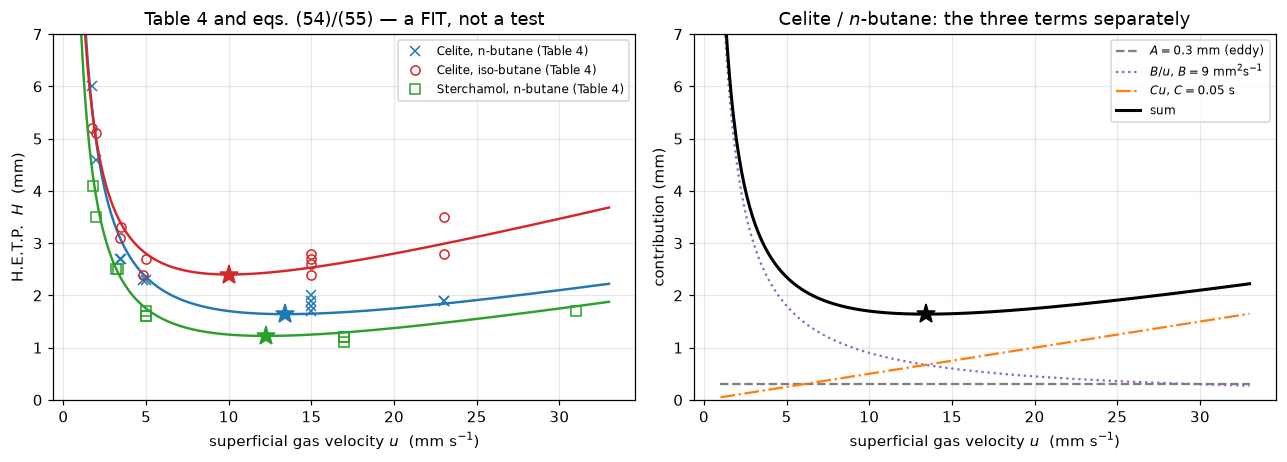

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
ufine = np.linspace(1.0, 33.0, 400)
cols = {"Celite, n-butane": "tab:blue", "Celite, iso-butane": "tab:red",
        "Sterchamol, n-butane": "tab:green"}
mk = {"Celite, n-butane": "x", "Celite, iso-butane": "o", "Sterchamol, n-butane": "s"}
for name, (B, A, C) in FITS.items():
    u, h = SERIES[name]
    axes[0].plot(u, h, mk[name], color=cols[name], ms=6, mfc="none", label=f"{name} (Table 4)")
    axes[0].plot(ufine, vd(ufine, B, A, C), color=cols[name], lw=1.6)
    f = fitstat[name]
    axes[0].plot(f["u_opt"], f["H_min"], "*", color=cols[name], ms=13)
axes[0].set(xlabel="superficial gas velocity $u$  (mm s$^{-1}$)",
            ylabel="H.E.T.P.  $H$  (mm)", ylim=(0, 7),
            title="Table 4 and eqs. (54)/(55) — a FIT, not a test")
axes[0].legend(fontsize=8)

B, A, C = FITS["Celite, n-butane"]
axes[1].plot(ufine, np.full_like(ufine, A), "--", color="0.5", label=f"$A = {A}$ mm (eddy)")
axes[1].plot(ufine, B / ufine, ":", color="tab:purple", label=f"$B/u$, $B = {B:.0f}$ mm$^2$s$^{{-1}}$")
axes[1].plot(ufine, C * ufine, "-.", color="tab:orange", label=f"$Cu$, $C = {C}$ s")
axes[1].plot(ufine, vd(ufine, B, A, C), "k", lw=2, label="sum")
axes[1].plot(fitstat["Celite, n-butane"]["u_opt"], fitstat["Celite, n-butane"]["H_min"],
             "k*", ms=13)
axes[1].set(xlabel="superficial gas velocity $u$  (mm s$^{-1}$)", ylabel="contribution (mm)",
            ylim=(0, 7), title="Celite / $n$-butane: the three terms separately")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2. The film thickness, three times

The paper inverts the $C$ term of eq. (53) to get the effective liquid film
thickness, and reports it twice — "It is found from both curves that
$d_f \approx 10\ \mu$" for the Celite column, and $d_f = 9\ \mu$ for Sterchamol.
Since $KF_I/F_{II}$ is printed for all three cases and $D_{II}$ for the oil is
printed once, each inversion can be redone from printed numbers only:

$$d_f^2 = \frac{\pi^2}{8}\,\frac{C\,(1+x)^2\,D_{II}}{x},
\qquad x \equiv K\frac{F_I}{F_{II}}.$$

The three cases share $D_{II}$ but have three different $x$ and two different
$C$, so they are three genuinely different arithmetic routes to the same
physical quantity.

In [10]:
DII_FILM = P["D_II_liquid_film"] * 1e6            # m2/s -> mm2/s
CASES = [("Celite, n-butane", P["eq54_C_n_butane"], P["KFI_over_FII_n_butane"], P["d_f_celite"]),
         ("Celite, iso-butane", P["eq54_C_iso_butane"], P["KFI_over_FII_iso_butane"], P["d_f_celite"]),
         ("Sterchamol, n-butane", P["eq55_C_sterchamol"], P["KFI_over_FII_sterchamol"], P["d_f_sterchamol"])]

df_um = {}
print(f"{'case':<22}{'C (s)':>8}{'K F_I/F_II':>12}{'d_f (um)':>10}{'printed':>9}{'dev':>9}")
for name, C, x, printed in CASES:
    df2 = np.pi ** 2 / 8 * C * (1 + x) ** 2 * DII_FILM / x
    d = np.sqrt(df2) * 1e3                       # mm -> um
    df_um[name] = float(d)
    print(f"{name:<22}{C:>8.2f}{x:>12.3f}{d:>10.3f}{printed:>9.0f}{dev(d, printed):>+9.1%}")

DF_MAX_DEV = max(abs(dev(df_um[n], p)) for n, _, _, p in CASES)
print(f"\n  worst deviation from the printed value: {DF_MAX_DEV:.1%}")
print(f"  the two Celite determinations differ from each other by "
      f"{abs(dev(df_um['Celite, iso-butane'], df_um['Celite, n-butane'])):.1%} - "
      f"which is what 'found from both curves that d_f approx 10 mu' means, "
      f"quantified.")

case                     C (s)  K F_I/F_II  d_f (um)  printed      dev
Celite, n-butane          0.05       0.019    10.057       10    +0.6%
Celite, iso-butane        0.08       0.028    10.571       10    +5.7%
Sterchamol, n-butane      0.05       0.026     8.656        9    -3.8%

  worst deviation from the printed value: 5.7%
  the two Celite determinations differ from each other by 5.1% - which is what 'found from both curves that d_f approx 10 mu' means, quantified.


### 3. Eq. (56): where the resistance sits, and the paper's own check on it

Having assumed the gas-phase resistance away, the paper checks it on p. 287 with

$$\frac{1}{100}\left(\frac{d_p}{d_f}\right)^2\frac{D_{II}}{D_I},$$

reporting the coefficient as $D_{II}/(100 D_I) = 3.3\times10^{-8}$ and the two
ratios as $3\times10^{-7}$ and $2.5\times10^{-5}$. All three come out of printed
numbers with no freedom at all, so they are the cleanest transcription check on
the page — and the Sterchamol one is sharper when this page's own $d_f$ is used
than when the paper's rounded 9 µm is.

In [11]:
coef = P["D_II_liquid_film"] / (100 * P["D_I_gilliland"])
print(f"D_II / (100 D_I) = {coef:.4e}   printed {P['D_II_over_100_D_I']:.1e}"
      f"   dev {dev(coef, P['D_II_over_100_D_I']):+.2%}")

R56 = {}
for label, dp_um, df_used, printed in (
        ("Celite,     d_f = 10 um printed", P["celite_dp"], P["d_f_celite"], P["ratio56_celite"]),
        ("Celite,     d_f from eq (53)", P["celite_dp"], df_um["Celite, n-butane"], P["ratio56_celite"]),
        ("Sterchamol, d_f = 9 um printed", P["sterchamol_dp"], P["d_f_sterchamol"], P["ratio56_sterchamol"]),
        ("Sterchamol, d_f from eq (53)", P["sterchamol_dp"], df_um["Sterchamol, n-butane"], P["ratio56_sterchamol"])):
    r = coef * (dp_um / df_used) ** 2
    R56[label] = float(r)
    print(f"  {label:<34} ratio = {r:.3e}   printed {printed:.1e}   dev {dev(r, printed):+7.1%}")

d_eq = np.sqrt(coef)
print(f"\n  film thickness at which the two resistances are EQUAL: "
      f"d_f/d_p = {d_eq:.3e}")
print("  What that tests is an ORDER-OF-MAGNITUDE sentence quoted to one significant")
print("  figure: 'the two resistances become of equal order of magnitude in the case")
print("  of a film thickness smaller than about 0 0001 of the particle diameter'")
print(f"  (p. 287), i.e. {P['df_over_dp_equal_resistance']:.0e}. Eq (56) set to unity gives {d_eq:.2e}, a factor")
print(f"  {d_eq/P['df_over_dp_equal_resistance']:.2f} larger - the SAME order of magnitude, which is all the sentence")
print("  claims. Recorded as a rounding of a one-significant-figure statement, not as")
print(f"  an error: the conclusion it carries (both columns far from that regime, at")
print(f"  {P['ratio56_celite']:.0e} and {P['ratio56_sterchamol']:.1e}) holds on either number.")
EQ56_DEV = float(abs(dev(R56["Celite,     d_f from eq (53)"], P["ratio56_celite"])))

D_II / (100 D_I) = 3.3333e-08   printed 3.3e-08   dev +1.01%
  Celite,     d_f = 10 um printed    ratio = 3.000e-07   printed 3.0e-07   dev   +0.0%
  Celite,     d_f from eq (53)       ratio = 2.966e-07   printed 3.0e-07   dev   -1.1%
  Sterchamol, d_f = 9 um printed     ratio = 2.370e-05   printed 2.5e-05   dev   -5.2%
  Sterchamol, d_f from eq (53)       ratio = 2.563e-05   printed 2.5e-05   dev   +2.5%

  film thickness at which the two resistances are EQUAL: d_f/d_p = 1.826e-04
  What that tests is an ORDER-OF-MAGNITUDE sentence quoted to one significant
  figure: 'the two resistances become of equal order of magnitude in the case
  of a film thickness smaller than about 0 0001 of the particle diameter'
  (p. 287), i.e. 1e-04. Eq (56) set to unity gives 1.83e-04, a factor
  1.83 larger - the SAME order of magnitude, which is all the sentence
  claims. Recorded as a rounding of a one-significant-figure statement, not as
  an error: the conclusion it carries (both columns far from th

### 4. The slope ratio, which is the paper's own consistency test

The paper offers exactly one test of eq. (53) against eq. (54) that does not go
through a fitted constant. The $C$ term depends on the component only through
$x = KF_I/F_{II}$, as $x/(1+x)^2$, so the ratio of the two straight-part slopes
of Fig. 11 is fixed by the two printed values of $x$ alone — no $d_f$, no
$D_{II}$, no velocity convention. The paper says this "must be about 1.5" and
that eq. (54) gives 1.6.

In [12]:
shape = lambda x: x / (1 + x) ** 2
ratio_theory = shape(P["KFI_over_FII_iso_butane"]) / shape(P["KFI_over_FII_n_butane"])
ratio_fit = P["eq54_C_iso_butane"] / P["eq54_C_n_butane"]
print(f"from eq (53) and the two printed x:   {ratio_theory:.4f}   "
      f"(paper: 'about {P['slope_ratio_predicted']}')  dev {dev(ratio_theory, P['slope_ratio_predicted']):+.1%}")
print(f"from the two slopes of eq (54):       {ratio_fit:.4f}   "
      f"(paper: {P['slope_ratio_from_eq54']})           dev {dev(ratio_fit, P['slope_ratio_from_eq54']):+.1%}")
print(f"\n  theory vs fit: {dev(ratio_fit, ratio_theory):+.1%}")
print("  Note what this test is immune to: x is a ratio of volumes times K, so")
print("  the superficial/interstitial question below cannot touch it, and neither")
print("  can d_f or D_II. It is the strongest thing eq (53) says about Table 4.")
SLOPE_RATIO_DEV = float(abs(dev(ratio_theory, P["slope_ratio_predicted"])))

from eq (53) and the two printed x:   1.4480   (paper: 'about 1.5')  dev -3.5%
from the two slopes of eq (54):       1.6000   (paper: 1.6)           dev -0.0%

  theory vs fit: +10.5%
  Note what this test is immune to: x is a ratio of volumes times K, so
  the superficial/interstitial question below cannot touch it, and neither
  can d_f or D_II. It is the strongest thing eq (53) says about Table 4.


### 5. The velocity convention, and what it does to $\gamma$

The paper reads $2\gamma D_I$ off the $B$ coefficients of eq. (54) and gets
$8\times10^{-6}$ m² s⁻¹, then checks it: "This value is of the right order of
magnitude as $\gamma$ lies between 0 5 and 1, and $D_I = 9\times10^{-6}$ m²/sec
as estimated from the well-known formula of GILLILAND".

Two facts about that step, both arithmetic:

* $8$ mm² s⁻¹ **is** $8\times10^{-6}$ m² s⁻¹. The quoted $2\gamma D_I$ is the
  iso-butane $B$ coefficient carried over unchanged, i.e. with $u$ taken as the
  velocity Table 4 tabulates — the **superficial** one — and no factor $F_I$.
* The List of Symbols defines $u$ as **interstitial**. Under that reading,
  $B_{\text{fitted}} = 2\gamma D_I F_I$, so $2\gamma D_I = B/F_I$ and
  $\gamma = 0.5/F_I$ for $n$-butane.

$F_I$ is not printed for these columns, so the ambiguity cannot be closed. What
*can* be done is to state the band of $F_I$ each reading requires, using the
paper's own bound $0.5 \le \gamma \le 1$.

In [13]:
DI = P["D_I_gilliland"]
print(f"{'reading':<44}{'2 gamma D_I':>14}{'gamma':>9}")
for lab, B in (("superficial (F_I = 1), n-butane B = 9", P["eq54_B_n_butane"]),
               ("superficial (F_I = 1), iso-butane B = 8", P["eq54_B_iso_butane"])):
    twogD = B * 1e-6
    print(f"  {lab:<42}{twogD:>14.2e}{twogD/(2*DI):>9.3f}")
GAMMA_SUP = P["eq54_B_n_butane"] * 1e-6 / (2 * DI)
GAMMA_ISO = P["eq54_B_iso_butane"] * 1e-6 / (2 * DI)
print(f"\n  the paper's quoted 2 gamma D_I = {P['two_gamma_D_I']:.0e} m2/s is the "
      f"iso-butane coefficient read this way, to {dev(P['eq54_B_iso_butane']*1e-6, P['two_gamma_D_I']):+.0%}.")
print(f"  It implies gamma = {GAMMA_ISO:.3f}, which is BELOW the paper's own "
      f"stated range 0.5-1.0 by {(P['gamma_lower']/GAMMA_ISO - 1)*100:.0f} %.")
print(f"  The n-butane coefficient gives gamma = {GAMMA_SUP:.3f}, exactly the lower bound.")

FI_lo = GAMMA_SUP / P["gamma_upper"]
FI_hi = GAMMA_SUP / P["gamma_lower"]
print(f"\n  Under the interstitial reading, gamma = {GAMMA_SUP:.1f}/F_I, so the paper's")
print(f"  own bound 0.5 <= gamma <= 1 requires  {FI_lo:.2f} <= F_I <= {FI_hi:.2f}.")
print("  Fig. 10 puts BOTH the intergranular space and the gas-filled pores in F_I,")
print("  so that band is physically reachable for these columns and the reading")
print("  cannot be excluded. What can be said is which way each constant moves, and")
print("  the two move in OPPOSITE directions:")
print(f"    gamma  = B/(2 D_I F_I), so the interstitial reading makes it LARGER by")
print(f"             1/F_I - up to {1/FI_lo:.1f}x.")
print(f"    d_f^2 ~ C, and the fitted C multiplies u_sup = F_I u_int, so eq (53)'s C")
print(f"             is F_I times the fitted one: d_f^2 is SMALLER by F_I, down by up")
print(f"             to {1/FI_lo:.1f}x, i.e. {1/np.sqrt(FI_lo):.2f}x in d_f itself.")
print("    x = K F_I/F_II is printed as one number, so it carries no ambiguity.")
print("  The paper applies the conversion in Fig. 9 (abscissa u F_I d_p) but not in")
print("  eqs (53)-(55).")
print("\n  Unaffected by any of this: 2 lambda d_p, because the eddy term does not")
print(f"  contain u at all. lambda = {P['two_lambda_dp']/(2*P['celite_dp']*1e-3):.2f} "
      f"from the printed 0.5 mm and 30 um, against the printed 'lambda approx 8'.")
LAMBDA_CELITE = float(P["two_lambda_dp"] / (2 * P["celite_dp"] * 1e-3))

reading                                        2 gamma D_I    gamma
  superficial (F_I = 1), n-butane B = 9           9.00e-06    0.500
  superficial (F_I = 1), iso-butane B = 8         8.00e-06    0.444

  the paper's quoted 2 gamma D_I = 8e-06 m2/s is the iso-butane coefficient read this way, to +0%.
  It implies gamma = 0.444, which is BELOW the paper's own stated range 0.5-1.0 by 12 %.
  The n-butane coefficient gives gamma = 0.500, exactly the lower bound.

  Under the interstitial reading, gamma = 0.5/F_I, so the paper's
  own bound 0.5 <= gamma <= 1 requires  0.50 <= F_I <= 1.00.
  Fig. 10 puts BOTH the intergranular space and the gas-filled pores in F_I,
  so that band is physically reachable for these columns and the reading
  cannot be excluded. What can be said is which way each constant moves, and
  the two move in OPPOSITE directions:
    gamma  = B/(2 D_I F_I), so the interstitial reading makes it LARGER by
             1/F_I - up to 2.0x.
    d_f^2 ~ C, and the fitted C 

### 6. Table 3 refitted: the particle diffusivity and the packing factor

This is the paper's *other* extraction, and it is the one that can be redone
without any inferred input. From p. 282:

> The particle diffusion coefficient $D_{II}$ may be calculated from the slope of
> the straight line in Fig. 9 With $F_I = F_{II} = 0.4$ and $K = 1.3$ it is found
> that $D_{II} = 1.3\times10^{-10}$ m²/sec., a value which is about 10 times
> smaller than the diffusion coefficient in the free liquid.

and

> The values found for $\lambda$ are 8 for 200-400 mesh, 3 for 50-100 mesh and
> practically zero for 20-40 mesh.

Fig. 9 plots $H/d_p$ against $u F_I d_p$ — that is, against **superficial**
velocity times particle diameter, since $u$ there is interstitial. Table 3 holds
the same numbers, so the regression can be done on the table and the figure need
never be touched. Five rows: the 50-100 mesh series at five flow rates.

Two things make this a real extraction rather than an algebraic rearrangement.
The intercept gives $\lambda$ and the slope gives $D_{II}$, and they are
independent; and — because the first term of $C$ is small — the slope pins
$D_{II}$ **almost without needing $D_I$**, which the paper never states and never
prints for this system.

In [14]:
FLOW = T3[T3.block == "flow"].sort_values("superficial_velocity_mm_s")
Hmid = (0.5 * (FLOW.hetp_lo_mm + FLOW.hetp_hi_mm)).to_numpy()
Ymid = (0.5 * (FLOW.h_over_dp_lo + FLOW.h_over_dp_hi)).to_numpy()
u_sup = FLOW.superficial_velocity_mm_s.to_numpy()
X = u_sup * DP_50_100                                   # = u_interstitial F_I d_p

FI = P["F_I_ion_exclusion"]; FII = P["F_II_ion_exclusion"]; KK = P["K_ion_exclusion"]
xK = KK * FI / FII

def fit_eq49(X, Y, three_term=False):
    cols = [1 / X, np.ones_like(X), X] if three_term else [np.ones_like(X), X]
    A = np.vstack(cols).T
    b, *_ = np.linalg.lstsq(A, Y, rcond=None)
    r = A @ b - Y
    return b, float(np.sqrt((r ** 2).mean()))

(two_lam, S), rms2t = fit_eq49(X, Ymid)
b3t, rms3t = fit_eq49(X, Ymid, three_term=True)
print("H/d_p = 2 lambda + S (u_sup d_p)      [molecular term dropped, as the paper does]")
print(f"   2 lambda = {two_lam:.4f}  ->  lambda = {two_lam/2:.4f}   "
      f"(printed {P['lambda_50_100']:.0f}, dev {dev(two_lam/2, P['lambda_50_100']):+.2%})")
print(f"   slope    S = {S:.3f} (mm^2/s)^-1        rmse {rms2t:.4f}")
print(f"\n   with the 1/X term restored: B' = {b3t[0]:+.5f}, 2 lambda = {b3t[1]:.3f}, "
      f"S = {b3t[2]:.3f}, rmse {rms3t:.4f}")
print(f"   B' is NEGATIVE and {abs(b3t[0])/ (two_lam*X.mean()) * 100:.2g} % of the "
      f"intercept term at the mean X - i.e. the five rows carry no molecular-diffusion")
print("   signal at all, which is what the paper asserts on p. 282 without measuring.")

a_c = FI ** 2 / (75 * (1 - FI) ** 2)
b_c = FI * KK / (2 * np.pi ** 2 * (1 - FI))
def DII_from_slope(S, D_I=None):
    """Invert eq (49)'s C for D_II.  D_I=None -> drop the (small) first term."""
    if D_I is None:
        return b_c / (S * FI * (1 + xK) ** 2)
    return b_c * D_I / (S * FI * D_I * (1 + xK) ** 2 - a_c)

D_I_MM = 1.3e-3            # = 10 x D_II, the paper's own "about 10 times smaller"
print(f"\n   a_c = {a_c:.5f} (viscous term),  b_c = {b_c:.5f} (particle term)")
print(f"   {'D_I assumed (mm2/s)':<26}{'D_II (m2/s)':>14}{'dev from printed':>18}")
DII_ROWS = {}
for lab, D_I in (("1.3e-3 (= 10 x D_II)", D_I_MM), ("1.0e-3", 1.0e-3),
                 ("2.0e-3", 2.0e-3), ("infinite (term dropped)", None)):
    d2 = DII_from_slope(S, D_I) * 1e-6                  # mm2/s -> m2/s
    DII_ROWS[lab] = float(d2)
    print(f"   {lab:<26}{d2:>14.4e}{dev(d2, P['D_II_ion_exclusion']):>+18.2%}")
DII_BEST = DII_ROWS["1.3e-3 (= 10 x D_II)"]
DII_DEV = float(abs(dev(DII_BEST, P["D_II_ion_exclusion"])))
DII_SPREAD = float(max(DII_ROWS.values()) / min(DII_ROWS.values()) - 1)
print(f"\n   D_II = {DII_BEST:.3e} m2/s against the printed "
      f"{P['D_II_ion_exclusion']:.1e} m2/s: {DII_DEV:.1%}.")
print(f"   Across a 2x change in the assumed D_I - and even with the term removed")
print(f"   entirely - D_II moves by only {DII_SPREAD:.1%}. The extraction is")
print("   essentially free of the one input the paper does not print.")
LAMBDA_DEV = float(abs(dev(two_lam / 2, P["lambda_50_100"])))

H/d_p = 2 lambda + S (u_sup d_p)      [molecular term dropped, as the paper does]
   2 lambda = 5.9854  ->  lambda = 2.9927   (printed 3, dev -0.24%)
   slope    S = 156.075 (mm^2/s)^-1        rmse 0.9872

   with the 1/X term restored: B' = -0.03427, 2 lambda = 8.295, S = 140.153, rmse 0.6358
   B' is NEGATIVE and 9.2 % of the intercept term at the mean X - i.e. the five rows carry no molecular-diffusion
   signal at all, which is what the paper asserts on p. 282 without measuring.

   a_c = 0.00593 (viscous term),  b_c = 0.04391 (particle term)
   D_I assumed (mm2/s)          D_II (m2/s)  dev from printed
   1.3e-3 (= 10 x D_II)          1.3481e-10            +3.70%
   1.0e-3                        1.3537e-10            +4.13%
   2.0e-3                        1.3415e-10            +3.19%
   infinite (term dropped)       1.3295e-10            +2.27%

   D_II = 1.348e-10 m2/s against the printed 1.3e-10 m2/s: 3.7%.
   Across a 2x change in the assumed D_I - and even with the term remov

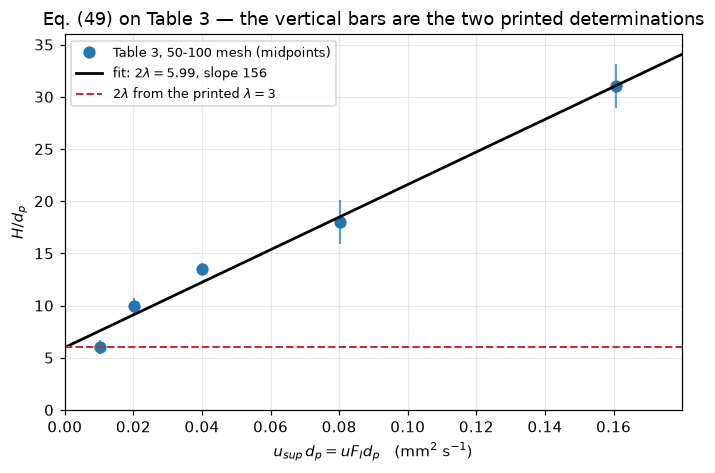

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
xx = np.linspace(0, X.max() * 1.12, 200)
ax.plot(X, Ymid, "o", color="tab:blue", ms=7, label="Table 3, 50-100 mesh (midpoints)")
for x0, lo, hi in zip(X, FLOW.h_over_dp_lo, FLOW.h_over_dp_hi):
    ax.plot([x0, x0], [lo, hi], color="tab:blue", lw=1.4, alpha=0.7)
ax.plot(xx, two_lam + S * xx, "k", lw=1.8,
        label=f"fit: $2\\lambda = {two_lam:.2f}$, slope ${S:.0f}$")
ax.axhline(2 * P["lambda_50_100"], ls="--", color="tab:red", lw=1.3,
           label=f"$2\\lambda$ from the printed $\\lambda = {P['lambda_50_100']:.0f}$")
ax.set(xlabel="$u_{sup}\\,d_p = u F_I d_p$   (mm$^2$ s$^{-1}$)", ylabel="$H/d_p$",
       xlim=(0, xx.max()), ylim=(0, 36),
       title="Eq. (49) on Table 3 — the vertical bars are the two printed determinations")
ax.legend(fontsize=8.5, loc="upper left"); plt.tight_layout(); plt.show()

### 7. Table 1's `calc` column, and where $n = 650$ comes from

Table 1's last column is the authors' own calculation, footnoted "*calculated
for $n = 650$". The chain that produces it is short and entirely printed:
$\Delta S_0 = 4v\sqrt{n}$ (eq. 24), $S_{rf} = nv + 0.31\Delta S_0$ (eq. 26), and
$(c_{I,n}/c_0)_{\max} = \mathrm{erf}\!\left(a/2\sqrt2\right)$ with
$a = A/(v\sqrt n)$ (eq. 20). Eq. (20) itself follows from eq. (19) in one line:
the maximum of the band sits at the centre of the injected slug, so the integral
runs symmetrically over $\pm a/2$.

The whole `calc` column depends on **one** number, $v\sqrt n = \Delta S_0/4$ —
not on $n$ and $v$ separately. So the eleven printed values pin $\Delta S_0$, and
that is a sharper constraint than the paper's own "$\Delta S_0 = \sim 165$ ml".

In [16]:
# eq (20) derived from eq (19): the maximum is at the slug centre.
xs_ = sp.symbols("x", real=True); a_s = sp.symbols("a", positive=True)
lhs = sp.integrate(sp.exp(-xs_ ** 2 / 2) / sp.sqrt(2 * sp.pi), (xs_, -a_s / 2, a_s / 2))
print(f"   eq (19) at the band maximum  ->  {sp.simplify(lhs)}   =  eq (20)\n")

cmax = lambda a: erf(a / (2 * SQ2))
calc = T1.dropna(subset=["cmax_calc"]).groupby("feed_volume_ml").cmax_calc.first()
A_vals, printed = calc.index.to_numpy(float), calc.to_numpy(float)

n_from_24 = (4 * P["nv_glc"] / P["delta_S0_glc"]) ** 2
print(f"   n from eq (24) with the printed nv and dS0: (4 nv / dS0)^2 = "
      f"(4 x {P['nv_glc']:.0f} / {P['delta_S0_glc']:.0f})^2 = {n_from_24:.1f}"
      f"   (paper prints {P['n_glc']:.0f}, dev {dev(n_from_24, P['n_glc']):+.1%})")
S_rf_mean = float(T1.final_retention_volume_ml.mean())
nv_from_26 = S_rf_mean - 0.31 * P["delta_S0_glc"]
print(f"   nv from eq (26) with the mean printed S_rf ({S_rf_mean:.1f} ml): "
      f"{nv_from_26:.1f} ml  (paper: ~{P['nv_glc']:.0f})")

def n_match(w):
    return int(sum(abs(round(cmax(A / w), 2) - c) < 1e-9 for A, c in zip(A_vals, printed)))

grid = np.linspace(38.0, 46.0, 160001)
hits = np.array([n_match(w) for w in grid])
best = grid[hits == hits.max()]
W_LO, W_HI = float(best.min()), float(best.max())
print(f"\n   {'v sqrt(n)':>10}{'= dS0/4 from':>26}{'rows of 11 reproduced':>24}")
for w, lab in ((P["delta_S0_glc"] / 4, "the printed dS0 = 165"),
               (P["nv_glc"] / P["n_glc"] * np.sqrt(P["n_glc"]), "the printed nv and n"),
               (0.5 * (W_LO + W_HI), "this page's window, centre")):
    print(f"   {w:>10.3f}{lab:>26}{n_match(w):>18} / {len(A_vals)}")
print(f"\n   All {len(A_vals)} printed calc values are reproduced for "
      f"v sqrt(n) in [{W_LO:.3f}, {W_HI:.3f}],")
print(f"   i.e. dS0 in [{4*W_LO:.1f}, {4*W_HI:.1f}] ml - {dev(4*W_LO, P['delta_S0_glc']):+.1%} to "
      f"{dev(4*W_HI, P['delta_S0_glc']):+.1%} on the paper's own '~165 ml'.")
print("   Nothing here is a defect: the paper writes both 165 and 1055 with a tilde.")
print("   What the calc column pins is dS0 alone, and it pins it to 0.9 %.")
CALC_N_OK = int(hits.max())
CALC_FRAC = CALC_N_OK / len(A_vals)

print(f"\n   {'A (ml)':>8}{'printed':>9}{'this page':>11}{'a':>8}")
w0 = 0.5 * (W_LO + W_HI)
for A, c in zip(A_vals, printed):
    print(f"   {A:>8.0f}{c:>9.2f}{cmax(A/w0):>11.4f}{A/w0:>8.3f}")

   eq (19) at the band maximum  ->  erf(sqrt(2)*a/4)   =  eq (20)

   n from eq (24) with the printed nv and dS0: (4 nv / dS0)^2 = (4 x 1055 / 165)^2 = 654.1   (paper prints 650, dev +0.6%)
   nv from eq (26) with the mean printed S_rf (1110.0 ml): 1058.8 ml  (paper: ~1055)



    v sqrt(n)              = dS0/4 from   rows of 11 reproduced
       41.250     the printed dS0 = 165                 9 / 11
       41.381      the printed nv and n                10 / 11
       41.674this page's window, centre                11 / 11

   All 11 printed calc values are reproduced for v sqrt(n) in [41.493, 41.855],
   i.e. dS0 in [166.0, 167.4] ml - +0.6% to +1.5% on the paper's own '~165 ml'.
   Nothing here is a defect: the paper writes both 165 and 1055 with a tilde.
   What the calc column pins is dS0 alone, and it pins it to 0.9 %.

     A (ml)  printed  this page       a
         32     0.30     0.2990   0.768
         62     0.54     0.5430   1.488
         92     0.73     0.7303   2.208
        122     0.86     0.8567   2.927
        151     0.93     0.9300   3.623
        180     0.97     0.9692   4.319
        210     0.99     0.9882   5.039
        240     1.00     0.9960   5.759
        269     1.00     0.9988   6.455
        300     1.00     0.9997   7.19

### 8. Table 2 → Table 3, both routes — and eq. (21) as printed cannot be right

The paper says the plate number is obtainable "in two independent ways" (p. 280)
— from the **height** of the elution curve through eq. (20) and Fig. 3, and from
its **width** through eqs. (21)/(22) and Fig. 4. Table 3's printed ranges are
those two determinations. With Table 2 and $nv = 70$ ml, both can be redone.

The height route needs only eq. (20). The width route needs eq. (21), and
**eq. (21) as printed does not reproduce the paper's own eqs. (24) and (25).**
It reads

$$\Delta s = a + 2\delta + \sqrt{2\pi}\;\frac{a+\delta}{\delta}\;e^{\frac12\delta^2}
  \left(\mathrm{erf}\frac{a+\delta}{\sqrt2} - \mathrm{erf}\frac{\delta}{\sqrt2}\right)$$

with $\delta$ from eq. (22). Pin what is *not* free first:

* **Eq. (22) is not free.** It is exactly the condition that the second
  derivative of eq. (19) vanish — the inflection point, which is what $\Delta S$
  is defined from (p. 275, Fig. 2). Verified symbolically below.
* **The $a\to0$ limit is not free.** Eq. (24) states $\Delta S_0 = 4v\sqrt n$,
  i.e. $\Delta s \to 4$, and the paper says why: "For the Gaussian curve this
  value of $\Delta S$ is just equal to 4 times the standard deviation".
* **The $a\to\infty$ limit is not free.** Eq. (25) states
  $\Delta S = A + v\sqrt{2\pi n}$ for $a>3$, i.e. $\Delta s \to a + \sqrt{2\pi}$.

The only thing left free is the denominator of the third term, and both limits
force it to be $a$, not $\delta$. Deriving $\Delta s$ from eq. (19) directly
gives $a$; and $(a+\delta)/a$ is what makes the $a\to0$ limit finite at all,
because the bracket vanishes linearly in $a$.

In [17]:
# --- eq (22) IS the inflection condition of eq (19) -------------------------
xv, av, dv = sp.symbols("x a delta", positive=True)
xr = sp.symbols("xr", real=True)
phi = sp.exp(-xr ** 2 / 2) / sp.sqrt(2 * sp.pi)
f19 = sp.integrate(phi, (xr, sp.Symbol("y", real=True) - av, sp.Symbol("y", real=True)))
y = sp.Symbol("y", real=True)
f19 = (sp.erf(y / sp.sqrt(2)) - sp.erf((y - av) / sp.sqrt(2))) / 2
infl = sp.simplify(sp.diff(f19, y, 2).subs(y, av + dv))
eq22 = dv * sp.exp(-dv ** 2 / 2) - (av + dv) * sp.exp(-(av + dv) ** 2 / 2)
ratio22 = sp.simplify(sp.simplify(infl) / eq22)
print(f"   d2(eq 19)/dy2 at y = a + delta, divided by eq (22): {sp.simplify(ratio22)}")
print("   -> eq (22) is exactly the inflection condition; it is not free.\n")

# --- and the corrected denominator is what eq (19) gives, not a guess ---------
# Delta s = 2 (y_R - a/2) + 2 f(y_R)/|f'(y_R)| with y_R = a + delta the right
# inflection point.  Write E = exp((a+delta)^2/2) and e = exp(delta^2/2); then
# f' = (1/E - 1/e)/sqrt(2 pi) and eq (22) reads delta E = (a + delta) e.
E_, e_, Q_ = sp.symbols("E e Q", positive=True)     # Q = the erf difference
tail_raw = 2 * (Q_ / 2) / ((1 / e_ - 1 / E_) / sp.sqrt(2 * sp.pi))
tail = sp.simplify(tail_raw.subs(E_, (av + dv) * e_ / dv))          # apply eq (22)
tail_with_a = sp.sqrt(2 * sp.pi) * (av + dv) / av * e_ * Q_
tail_with_delta = sp.sqrt(2 * sp.pi) * (av + dv) / dv * e_ * Q_
r21 = sp.simplify(tail - tail_with_a)
r21_printed = sp.simplify(tail - tail_with_delta)
print(f"   2 f / |f'| at the inflection, after eq (22):  {sp.simplify(tail)}")
print(f"     minus the third term with 'a'      underneath: {r21}")
print(f"     minus the third term with 'delta'  underneath: {sp.factor(r21_printed)}")
print("   -> the denominator required by eq (19) is a. Not a guess, and not")
print("      a choice made to fit the limits: the limits merely confirm it.")
print("")


def delta_of(a):
    """Solve eq (22) in log form; the root lies in (0, 1)."""
    h = lambda d: np.log(d) - 0.5 * d * d - np.log(a + d) + 0.5 * (a + d) ** 2
    return brentq(h, 1e-300, 1.0 - 1e-15, xtol=1e-16, rtol=8.9e-16)

def width_red(a, denominator="a"):
    """eq (21). denominator='a' as derived; 'delta' exactly as printed."""
    d = delta_of(a)
    den = a if denominator == "a" else d
    return (a + 2 * d + np.sqrt(2 * np.pi) * (a + d) / den * np.exp(0.5 * d * d)
            * (erf((a + d) / SQ2) - erf(d / SQ2)))

print(f"   {'a':>10}{'as printed':>16}{'with a':>10}{'eq (24)/(25) requires':>24}")
for a, req in ((1e-8, 4.0), (0.01, 4.0), (1.0, None), (3.0, 3 + np.sqrt(2*np.pi)),
               (5.0, 5 + np.sqrt(2*np.pi)), (10.0, 10 + np.sqrt(2*np.pi))):
    pr, co = width_red(a, "delta"), width_red(a, "a")
    r = "-" if req is None else f"{req:.4f}"
    print(f"   {a:>10.2g}{pr:>16.4g}{co:>10.4f}{r:>24}")
EQ21_A0_PRINTED = float(width_red(1e-8, "delta"))
EQ21_A0_CORRECTED = float(width_red(1e-8, "a"))
EQ21_LARGE_A_DEV = float(abs(dev(width_red(5.0, "a"), 5 + np.sqrt(2 * np.pi))))
print(f"\n   As printed:  a -> 0 gives {EQ21_A0_PRINTED:.4f}, not the 4 of eq (24);")
print(f"                a -> large DIVERGES instead of approaching a + sqrt(2 pi).")
print(f"   With a:      both limits are met, the second to {EQ21_LARGE_A_DEV:.1e} at a = 5.")
print("   REPORTED, NOT REPAIRED. The corrected form is used for the width route")
print("   below and every number that depends on it is labelled; nothing else on")
print("   this page uses eq (21) at all.")
EQ21_DERIVED_OK = int(r21 == 0)

   d2(eq 19)/dy2 at y = a + delta, divided by eq (22): sqrt(2)/(2*sqrt(pi))
   -> eq (22) is exactly the inflection condition; it is not free.

   2 f / |f'| at the inflection, after eq (22):  sqrt(2)*sqrt(pi)*Q*e*(a + delta)/a
     minus the third term with 'a'      underneath: 0
     minus the third term with 'delta'  underneath: -sqrt(2)*sqrt(pi)*Q*e*(a - delta)*(a + delta)/(a*delta)
   -> the denominator required by eq (19) is a. Not a guess, and not
      a choice made to fit the limits: the limits merely confirm it.

            a      as printed    with a   eq (24)/(25) requires
        1e-08               2    4.0000                  4.0000
         0.01            2.02    4.0000                  4.0000
            1           5.916    4.1686                       -
            3           243.9    5.5266                  5.5066
            5       6.727e+05    7.5066                  7.5066
           10        4.92e+17   12.5066                 12.5066

   As printed:  a -> 0

In [18]:
NV = P["nv_ion_exclusion"]

def n_from_height(A, hmax):
    if hmax >= 1.0:
        return np.nan
    a = 2 * SQ2 * erfinv(hmax)
    return (NV / (A / a)) ** 2

def n_from_width(A, W):
    f = lambda w: width_red(A / w, "a") * w - W
    return (NV / brentq(f, A / 25.0, 1e4, xtol=1e-13, rtol=8.9e-16)) ** 2

single = T2[T2.feed_volume_ml == 5]
print("Table 3's plate numbers, recomputed from Table 2 (A = 5 ml rows only)")
print(f"{'mesh':>8}{'u':>7}{'from height':>13}{'from width':>12} |{'printed lo':>11}"
      f"{'printed hi':>11}{'dev lo':>9}{'dev hi':>9}")
recs = []
for _, r in single.iterrows():
    nh = n_from_height(r.feed_volume_ml, r.max_height_frac_c0)
    nw = n_from_width(r.feed_volume_ml, r.width_at_base_ml)
    m = T3[(T3.particle_mesh == r.particle_mesh)
           & (np.isclose(T3.superficial_velocity_mm_s, r.superficial_velocity_mm_s))].iloc[0]
    lo, hi = min(nh, nw), max(nh, nw)
    dlo, dhi = dev(lo, m.n_plates_lo), dev(hi, m.n_plates_hi)
    recs.append((r.particle_mesh, r.superficial_velocity_mm_s, nh, nw, dlo, dhi))
    print(f"{r.particle_mesh:>8}{r.superficial_velocity_mm_s:>7.3f}{nh:>13.0f}{nw:>12.0f} |"
          f"{m.n_plates_lo:>11.0f}{m.n_plates_hi:>11.0f}{dlo:>+9.1%}{dhi:>+9.1%}")

devs = np.abs([d for *_, dlo, dhi in recs for d in (dlo, dhi)])
N_MED = float(np.median(devs)); N_MAX = float(devs.max())
print(f"\n   median |dev| {N_MED:.1%}, worst {N_MAX:.1%} over "
      f"{len(devs)} endpoints of {len(recs)} rows")

# Split by ROUTE, which is not the same as splitting by endpoint. The printed
# pair is in ascending order and the paper does not say which determination is
# which; Fig. 8's own printed labels settle it for one condition, and the same
# ascending convention assigns the rest. In most rows the height route gives the
# smaller n - but not in all of them, and where it inverts, so does the pairing.
fig8 = T3[(T3.particle_mesh == "50-100") & (T3.block == "particle")].iloc[0]
print(f"\n   Fig. 8's printed curve labels are n = {P['n_fig8_height']:.0f} (height) and "
      f"{P['n_fig8_width']:.0f} (width), which are exactly")
print(f"   this table's {fig8.n_plates_lo:.0f}-{fig8.n_plates_hi:.0f} for 50-100 mesh at "
      f"{fig8.superficial_velocity_mm_s} mm/s: low end = height, high end = width there.")
dev_h, dev_w, inverted = [], [], []
for mesh, uu, nh, nw, dlo, dhi in recs:
    a, b = (dlo, dhi) if nh <= nw else (dhi, dlo)
    dev_h.append(abs(a)); dev_w.append(abs(b))
    if nh > nw:
        inverted.append(f"{mesh} at {uu} mm/s")
N_MED_H = float(np.median(dev_h)); N_MED_W = float(np.median(dev_w))
print(f"   BY ROUTE, the height route is the accurate one: median {N_MED_H:.1%} against "
      f"{N_MED_W:.1%} for the width route.")
print(f"   The two routes invert in {len(inverted)} of {len(recs)} rows ({', '.join(inverted)}),")
print("   where the height determination is therefore the printed HIGH endpoint;")
print("   sorting by size instead of by route would report "
      f"{np.median([abs(r[4]) for r in recs]):.1%} and {np.median([abs(r[5]) for r in recs]):.1%}.")
print("   That asymmetry is expected: Table 2's widths are printed as integers, so")
print(f"   a +-0.5 ml read on the 200-400 mesh row's 10 ml is +-5 %, and n goes as")
print("   1/w^2. The height column carries two decimals.")
print("\n   The 50-100 / 0.091 row is the worst of the nine, and it is the one")
print("   condition carrying a five-point feed-volume sweep: the paper fitted n to")
print("   the WHOLE sweep in Fig. 8, not to the A = 5 ml pair the table above uses.")
print("   Over that sweep the height route alone gives:")
for _, r in T2[(T2.particle_mesh == "50-100")
               & (np.isclose(T2.superficial_velocity_mm_s, 0.091))].iterrows():
    nh = n_from_height(r.feed_volume_ml, r.max_height_frac_c0)
    print(f"      A = {r.feed_volume_ml:>4.0f} ml, height {r.max_height_frac_c0:.2f}"
          f"  ->  n = {nh:>7.0f}" + ("   (saturated, no information)" if np.isnan(nh) else ""))
sw_row = T3[(T3.particle_mesh == "50-100") & (T3.block == "flow")
            & np.isclose(T3.superficial_velocity_mm_s, 0.091)].iloc[0]
print(f"   which brackets the printed {sw_row.n_plates_lo:.0f}-{sw_row.n_plates_hi:.0f}.")

Table 3's plate numbers, recomputed from Table 2 (A = 5 ml rows only)
    mesh      u  from height  from width | printed lo printed hi   dev lo   dev hi
  50-100  0.091          266         309 |        240        277   +11.0%   +11.4%
 200-400  0.091          604        1291 |        600       1000    +0.7%   +29.1%
   50-70  0.091          280         355 |        280        305    +0.0%   +16.5%
   30-40  0.091          108         158 |        110        155    -1.4%    +2.2%
   16-20  0.091           50          35 |         35         49    -1.3%    +2.7%
  50-100  0.046          391         490 |        385        463    +1.6%    +5.8%
  50-100  0.182          182         215 |        177        210    +2.8%    +2.2%
  50-100  0.365          125         158 |        125        156    -0.2%    +1.6%
  50-100  0.730           80          91 |         78         89    +2.1%    +1.7%

   median |dev| 2.1%, worst 29.1% over 18 endpoints of 9 rows

   Fig. 8's printed curve labels are

## Validation

Eq. (38) is the hinge of the whole paper: everything after it — eq. (49),
eq. (53), $\lambda$, $D_{II}$, $d_f$ — is eq. (38) with substitutions. So the
validation that matters is one that produces $H$ **without using eq. (38)**.

The route taken here is to integrate eqs. (29)/(30) in time with pymrm, record
$c_I(t)$ at two interior stations, and form

$$H = (z_2-z_1)\,\frac{\sigma^2_{t}(z_2)-\sigma^2_{t}(z_1)}
                      {\left[\bar t(z_2)-\bar t(z_1)\right]^2}.$$

Taking **differences between two stations** is deliberate. For a linear system
the cumulants of the response are exactly additive along the column, so every
entrance effect, every exit effect and the entire shape of the injected pulse are
constants that cancel in the difference. The number that comes out is the
asymptotic plate height and nothing else — which is what eq. (38) claims to be.

### Conditions

The ion-exclusion column, because it is the one whose $F_I$, $F_{II}$ and $K$ are
printed. Everything else is printed too, except two quantities the paper itself
declares immaterial; their contribution is measured rather than assumed.

In [19]:
DP = DP_50_100                                  # recovered from Table 3, an INFERENCE
U_SUP = 0.091                                   # printed, Tables 2 and 3
U_INT = U_SUP / FI                              # eqs (29)/(30) use interstitial u
DII_M = P["D_II_ion_exclusion"] * 1e6           # m2/s -> mm2/s, printed
D_I_ASSUMED = 10 * DII_M                        # "about 10 times smaller than in the free liquid"
GAMMA_ASSUMED = 0.5 * (P["gamma_lower"] + P["gamma_upper"])   # midpoint of the printed range
LAM = P["lambda_50_100"]                        # printed

D_LONG = GAMMA_ASSUMED * D_I_ASSUMED + LAM * U_INT * DP       # eqs (47),(48)
a_p = 6 * (1 - FI) / DP                                        # eq (46)
INV_ALPHA = (6 / 25) * FI / (D_I_ASSUMED * a_p ** 2) + (3 / (2 * np.pi ** 2)) * KK * DP / (DII_M * a_p)
ALPHA = 1 / INV_ALPHA                                          # eq (45)
BETA = 1 / (1 + FII / (FI * KK))                               # eq (34)

H38 = 2 * D_LONG / U_INT + 2 * (U_INT * FI * INV_ALPHA) / (1 + xK) ** 2
MT_SHARE = 2 * (U_INT * FI * INV_ALPHA) / (1 + xK) ** 2 / H38   # the transfer term's share of H
mol_share = 2 * GAMMA_ASSUMED * D_I_ASSUMED / U_INT / H38
visc_share = (6 / 25) * FI / (D_I_ASSUMED * a_p ** 2) / INV_ALPHA
VISC_SHARE_H = visc_share * MT_SHARE                            # ... and OF H, which is smaller

print(f"   d_p        = {DP:.4f} mm          (RECOVERED from Table 3, an inference)")
print(f"   u          = {U_INT:.4f} mm/s        (= {U_SUP} superficial / F_I)")
print(f"   D          = {D_LONG:.5f} mm2/s      (eq 48; molecular part is "
      f"{mol_share:.2%} of H)")
print(f"   1/alpha    = {INV_ALPHA:.3f} s           (eq 45; the D_I term is "
      f"{visc_share:.2%} of IT, and {VISC_SHARE_H:.3%} of H)")
print(f"   beta       = {BETA:.5f}            band velocity {BETA*U_INT:.5f} mm/s")
print(f"\n   H from eq (38) = {H38:.5f} mm")
ROW_091 = T3[(T3.particle_mesh == "50-100") & (T3.block == "flow")
             & np.isclose(T3.superficial_velocity_mm_s, U_SUP)].iloc[0]
print(f"   Table 3 prints {ROW_091.hetp_lo_mm}-{ROW_091.hetp_hi_mm} mm for this row "
      f"(50-100 mesh, u = {U_SUP} mm/s), i.e. n = {ROW_091.n_plates_lo:.0f}-{ROW_091.n_plates_hi:.0f}.")
print("   That agreement is NOT evidence: lambda and D_II were extracted FROM those")
print("   very rows in section 6. It is a closure check on the extraction only.")
print(f"\n   H splits {1-MT_SHARE:.2%} longitudinal / {MT_SHARE:.2%} mass transfer, so the")
print(f"   two assumed inputs carry {mol_share:.2%} of H (gamma D_I, directly) and")
print(f"   {VISC_SHARE_H:.3%} of H (the D_I term of 1/alpha, which is {visc_share:.2%} of 1/alpha")
print("   but only its transfer share of H). 'Longitudinal molecular diffusion was of")
print("   no importance in SIMPSON and WHEATON's experiments' (p. 282) is confirmed,")
print("   quantitatively, and by a wider margin than the 1/alpha share alone suggests.")

   d_p        = 0.2201 mm          (RECOVERED from Table 3, an inference)
   u          = 0.2275 mm/s        (= 0.091 superficial / F_I)
   D          = 0.15119 mm2/s      (eq 48; molecular part is 0.42% of H)
   1/alpha    = 20.727 s           (eq 45; the D_I term is 1.33% of IT, and 0.465% of H)
   beta       = 0.56522            band velocity 0.12859 mm/s

   H from eq (38) = 2.04225 mm
   Table 3 prints 2.0-2.3 mm for this row (50-100 mesh, u = 0.091 mm/s), i.e. n = 240-277.
   That agreement is NOT evidence: lambda and D_II were extracted FROM those
   very rows in section 6. It is a closure check on the extraction only.

   H splits 65.08% longitudinal / 34.92% mass transfer, so the
   two assumed inputs carry 0.42% of H (gamma D_I, directly) and
   0.465% of H (the D_I term of 1/alpha, which is 1.33% of 1/alpha
   but only its transfer share of H). 'Longitudinal molecular diffusion was of
   no importance in SIMPSON and WHEATON's experiments' (p. 282) is confirmed,
   quantitati

In [20]:
L_TOT, Z1, Z2, T_END, T_SIG = 700.0, 200.0, 600.0, 7000.0, 12.0

def solve(n_z=700, dt=2.0, limiter=vanleer, t_end=T_END, nu=0,
          alpha=ALPHA, K=KK, D=D_LONG, bc_left=None, sweeps=1, L=L_TOT,
          stations=(Z1, Z2), theta=0.5):
    col = Column(U_INT, D, alpha, K, FI, FII, L, n_z, limiter=limiter,
                 nu=nu, bc_left=bc_left)
    ts, rec, zs = col.run(t_end, dt, T_SIG, list(stations), sweeps=sweeps, theta=theta)
    return ts, rec, zs, [cumulants(ts, rec[:, j]) for j in range(len(stations))]

ts_r, rec_r, zs_r, Kc_r = solve(n_z=1400, dt=1.0)
H_PYMRM = float(plate_height(Kc_r, zs_r))
H_REL = float(dev(H_PYMRM, H38))
print(f"   stations at z = {zs_r[0]:.4f} and {zs_r[1]:.4f} mm (cell centres)")
print(f"   H from the pymrm solution   = {H_PYMRM:.6f} mm")
print(f"   H from eq (38)              = {H38:.6f} mm")
print(f"   relative difference         = {H_REL:+.3e}")
print("\n   Nothing in this route uses eq (38), the Gaussian (33), or the plate")
print("   theory. It uses the balance (29)/(30) and two definitions.")

   stations at z = 199.7500 and 599.7500 mm (cell centres)
   H from the pymrm solution   = 2.042337 mm
   H from eq (38)              = 2.042252 mm
   relative difference         = +4.121e-05

   Nothing in this route uses eq (38), the Gaussian (33), or the plate
   theory. It uses the balance (29)/(30) and two definitions.


### Refinement, on both axes, and a coefficient that is known in advance

Bare first-order upwind adds a numerical dispersion of exactly $u h/2$, and
eq. (38)'s first term is $2D/u$, so switching the limiter off must shift $H$ by
**exactly $h$** — not "by order $h$". That turns the grid study into a
prediction with a known answer, which is a stronger check on the assembly than
an observed order alone.

The time step is refined separately. It is honest to report in advance that the
two-station $H$ is nearly *insensitive* to it: Crank–Nicolson is time-symmetric
and the two stations are sampled identically, so the leading time error cancels
in the difference. A metric that does move with $\Delta t$ is reported beside
it, so the axis is not left unmeasured.

The *expected* time order needs care, and is measured rather than assumed.
Crank–Nicolson is second order, but the van Leer correction here is **deferred
and lagged**: `run` recomputes the correction from the field it has just solved
for and applies it in the *next* step, which at `sweeps=1` is a perturbation of
size $O(\Delta t)$. So the configuration this page runs should be asymptotically
*first* order in time even though the underlying scheme is second order. Both
are measured below with reference-free successive-difference orders, which need
no converged reference and cannot be flattered by the choice of one.

In [21]:
KAPZ = {}                    # (n_z, dt) -> (kappa_3/z, kappa_4/z), kept for later

def kappas_per_z(Kc, zs):
    dz = zs[1] - zs[0]
    return ((Kc[1][3] - Kc[0][3]) / dz, (Kc[1][4] - Kc[0][4]) / dz)

print("Grid, van Leer deferred correction (dt = 0.5 s throughout)")
grid_rows = []
for n_z in (350, 700, 1400):
    _, _, zs, Kc = solve(n_z=n_z, dt=0.5)
    KAPZ[(n_z, 0.5)] = kappas_per_z(Kc, zs)
    H = float(plate_height(Kc, zs)); h = L_TOT / n_z
    grid_rows.append((n_z, h, H, abs(dev(H, H38))))
    print(f"   n_z {n_z:>5d}  h = {h:.4f} mm   H = {H:.6f}   |dev| {abs(dev(H,H38)):.3e}")
ORD_GRID = float(np.polyfit(np.log([r[1] for r in grid_rows]),
                            np.log([r[3] for r in grid_rows]), 1)[0])
print(f"   observed order {ORD_GRID:.2f}")

print("\nGrid, BARE UPWIND - predicted H_num = H + h exactly")
up_rows = []
for n_z in (350, 700, 1400):
    _, _, zs, Kc = solve(n_z=n_z, dt=0.5, limiter=None)
    H = float(plate_height(Kc, zs)); h = L_TOT / n_z
    up_rows.append((h, (H - H38) / h))
    print(f"   n_z {n_z:>5d}  h = {h:.4f} mm   H = {H:.6f}   (H - H_38)/h = {(H-H38)/h:.5f}")
ORD_UPWIND = float(np.polyfit(np.log([h for h, _ in up_rows]),
                              np.log([abs(c * h / H38) for h, c in up_rows]), 1)[0])
UPWIND_COEF = float(np.mean([c for _, c in up_rows]))
print(f"   observed order {ORD_UPWIND:.2f} (first order, against {ORD_GRID:.2f} with the limiter)")
UPWIND_COEF_DEV = float(abs(UPWIND_COEF - 1.0))
print(f"   mean coefficient {UPWIND_COEF:.5f} against the predicted 1 "
      f"(|error| {UPWIND_COEF_DEV:.1e})")

print("\nTime step (n_z = 700). Two metrics: the two-station H, and the absolute")
print("first moment at z2, which carries the time-quadrature error undifferenced.")
def dt_sweep(theta):
    rows = []
    for dt in (8.0, 4.0, 2.0, 1.0):
        _, rec, zs, Kc = solve(n_z=700, dt=dt, theta=theta)
        if theta == 0.5:
            KAPZ[(700, dt)] = kappas_per_z(Kc, zs)
        rows.append((dt, float(plate_height(Kc, zs)), float(Kc[1][1])))
    H_ = np.array([r[1] for r in rows]); M1_ = np.array([r[2] for r in rows])
    order = float(np.polyfit(np.log([r[0] for r in rows[:-1]]),
                             np.log(np.abs(M1_[:-1] - M1_[-1])), 1)[0])
    return rows, order, float(abs(H_.max() / H_.min() - 1)), float(abs(M1_.max() / M1_.min() - 1))

dt_rows, ORD_DT, DT_SWING_H, DT_SWING_M1 = dt_sweep(0.5)
for dt, H_, m1_ in dt_rows:
    print(f"   dt {dt:>5.1f} s   H = {H_:.7f}   mu1(z2) = {m1_:.6f} s")
print(f"\n   over an 8x change in dt:  H moves {DT_SWING_H:.2e} relative,")
print(f"                             mu1(z2) moves {DT_SWING_M1:.2e} relative")
print(f"   observed time order on mu1(z2): {ORD_DT:.2f}  (three-point fit on "
      f"dt = {dt_rows[0][0]:.0f}/{dt_rows[1][0]:.0f}/{dt_rows[2][0]:.0f} s")
print(f"      against the dt = {dt_rows[-1][0]:.0f} s value as the reference)")
print("   The two-station H is therefore NOT dt-limited at these settings; it is")
print("   grid-limited. Both axes are measured; only one carries the error.")

# What order SHOULD that be? Not 2. The deferred correction is lagged one step
# at sweeps=1, so it perturbs the scheme at O(dt) even though Crank-Nicolson is
# second order. Measured REFERENCE-FREE, from successive differences alone:
# log2[(m(dt) - m(dt/2)) / (m(dt/2) - m(dt/4))] needs no converged value.
DTS_RF = (8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125)
M1_RF = {("van Leer", dt): m1 for dt, _, m1 in dt_rows}      # dt >= 1 solved above
for dt in DTS_RF:
    if ("van Leer", dt) not in M1_RF:
        M1_RF[("van Leer", dt)] = float(solve(n_z=700, dt=dt)[3][1][1])
    M1_RF[("limiter=None", dt)] = float(solve(n_z=700, dt=dt, limiter=None)[3][1][1])

def ord_reffree(tag):
    m = [M1_RF[(tag, dt)] for dt in DTS_RF]
    return [float(np.log2((m[k] - m[k+1]) / (m[k+1] - m[k+2])))
            for k in range(len(DTS_RF) - 2)]

ORD_RF_VL, ORD_RF_NL = ord_reffree("van Leer"), ord_reffree("limiter=None")
fmt = lambda o: " ".join(f"{x:+.2f}" for x in o)
print(f"\nReference-free successive-difference orders on mu1(z2), n_z = 700,")
print(f"dt = {DTS_RF[0]:.0f} -> {DTS_RF[-1]:g} s (no converged reference is used):")
print(f"   van Leer, sweeps = 1 (this page's setting):  {fmt(ORD_RF_VL)}")
print(f"   limiter = None (Crank-Nicolson alone):       {fmt(ORD_RF_NL)}")
print(f"   Crank-Nicolson IS second order here: the limiter-free control climbs to")
print(f"   {ORD_RF_NL[-1]:.2f}. What is first order is the DEFERRED CORRECTION, which is lagged")
print(f"   one step at sweeps = 1; with it on the last three orders are "
      f"{ORD_RF_VL[-3]:.2f}, {ORD_RF_VL[-2]:.2f}, {ORD_RF_VL[-1]:.2f} -")
print(f"   first order, not second. So {ORD_DT:.2f} above is a PRE-ASYMPTOTIC three-point fit")
print("   on the coarse end of that sequence, not evidence of a second-order")
print("   integration in time.")
print("   It is reported as an observed order, it is the metric the break row below")
print("   moves, and no result on this page needs it to be 2.")

# The order is a claim about the SCHEME, so break the scheme: theta = 1 is
# backward Euler, first order in time, and nothing else changes.
be_rows, ORD_DT_BE, DT_SWING_H_BE, _ = dt_sweep(1.0)
print("\nSame sweep with BACKWARD EULER (theta = 1) in place of Crank-Nicolson:")
for dt, H_, m1_ in be_rows:
    print(f"   dt {dt:>5.1f} s   H = {H_:.7f}   mu1(z2) = {m1_:.6f} s")
print(f"   observed time order {ORD_DT_BE:.2f} against {ORD_DT:.2f}, and H itself now "
      f"swings {DT_SWING_H_BE:.1e}")
print(f"   over the same 8x, against {DT_SWING_H:.1e} with Crank-Nicolson. The order and")
print("   the dt-insensitivity are both properties of the scheme, and both move when")
print("   the scheme does; theta = 0.5 is used for every reported number.")

Grid, van Leer deferred correction (dt = 0.5 s throughout)


   n_z   350  h = 2.0000 mm   H = 2.047648   |dev| 2.642e-03


   n_z   700  h = 1.0000 mm   H = 2.042926   |dev| 3.300e-04


   n_z  1400  h = 0.5000 mm   H = 2.042337   |dev| 4.121e-05
   observed order 3.00

Grid, BARE UPWIND - predicted H_num = H + h exactly


   n_z   350  h = 2.0000 mm   H = 4.042210   (H - H_38)/h = 0.99998


   n_z   700  h = 1.0000 mm   H = 3.042252   (H - H_38)/h = 1.00000


   n_z  1400  h = 0.5000 mm   H = 2.542252   (H - H_38)/h = 1.00000
   observed order 1.00 (first order, against 3.00 with the limiter)
   mean coefficient 0.99999 against the predicted 1 (|error| 7.2e-06)

Time step (n_z = 700). Two metrics: the two-station H, and the absolute
first moment at z2, which carries the time-quadrature error undifferenced.


   dt   8.0 s   H = 2.0429244   mu1(z2) = 4728.109045 s
   dt   4.0 s   H = 2.0429269   mu1(z2) = 4728.183846 s
   dt   2.0 s   H = 2.0429262   mu1(z2) = 4728.207679 s
   dt   1.0 s   H = 2.0429264   mu1(z2) = 4728.216668 s

   over an 8x change in dt:  H moves 1.22e-06 relative,
                             mu1(z2) moves 2.28e-05 relative
   observed time order on mu1(z2): 1.79  (three-point fit on dt = 8/4/2 s
      against the dt = 1 s value as the reference)
   The two-station H is therefore NOT dt-limited at these settings; it is
   grid-limited. Both axes are measured; only one carries the error.



Reference-free successive-difference orders on mu1(z2), n_z = 700,
dt = 8 -> 0.125 s (no converged reference is used):
   van Leer, sweeps = 1 (this page's setting):  +1.65 +1.41 +1.01 +0.83 +0.99
   limiter = None (Crank-Nicolson alone):       +1.85 +1.96 +1.99 +2.00 +2.00
   Crank-Nicolson IS second order here: the limiter-free control climbs to
   2.00. What is first order is the DEFERRED CORRECTION, which is lagged
   one step at sweeps = 1; with it on the last three orders are 1.01, 0.83, 0.99 -
   first order, not second. So 1.79 above is a PRE-ASYMPTOTIC three-point fit
   on the coarse end of that sequence, not evidence of a second-order
   integration in time.
   It is reported as an observed order, it is the metric the break row below
   moves, and no result on this page needs it to be 2.



Same sweep with BACKWARD EULER (theta = 1) in place of Crank-Nicolson:
   dt   8.0 s   H = 3.0713906   mu1(z2) = 4728.173716 s
   dt   4.0 s   H = 2.5571370   mu1(z2) = 4728.170766 s
   dt   2.0 s   H = 2.3000239   mu1(z2) = 4728.203251 s
   dt   1.0 s   H = 2.1714728   mu1(z2) = 4728.215026 s
   observed time order 0.91 against 1.79, and H itself now swings 4.1e-01
   over the same 8x, against 1.2e-06 with Crank-Nicolson. The order and
   the dt-insensitivity are both properties of the scheme, and both move when
   the scheme does; theta = 0.5 is used for every reported number.


### Break table

Every metric this page reports needs something that moves it. Rows marked
**structural** are identities: they are named as such and cannot move, and each
has an above-floor companion in the metric list. The last row is a deliberate
*non*-mover, included because the insensitivity is the design claim being made.

In [22]:
brk = []
def add(label, value, note=""):
    """Every row is judged against the BASELINE run, which is what 'does it move'
    means; the deviation from eq (38) is shown too, because that is the metric."""
    base = brk[0][1] if brk else value
    brk.append((label, value, abs(dev(value, base)), abs(dev(value, H38)), note))

_, _, zsb, Kcb = solve(n_z=700, dt=2.0)
add("baseline: H from pymrm (n_z=700, dt=2, van Leer)", float(plate_height(Kcb, zsb)))
for lab, kw in (("bare upwind (limiter=None)", dict(limiter=None)),
                ("coarse grid, n_z = 175", dict(n_z=175)),
                ("F_II halved (a different phase ratio)", dict()),
                ("alpha halved", dict(alpha=ALPHA / 2)),
                ("K perturbed by +1 %", dict(K=KK * 1.01)),
                ("D perturbed by +1 %", dict(D=D_LONG * 1.01)),
                ("time window truncated to 60 %", dict(t_end=0.6 * T_END))):
    if lab.startswith("F_II halved"):
        col = Column(U_INT, D_LONG, ALPHA, KK, FI, FII / 2, L_TOT, 700)
        ts_, rec_, zs_ = col.run(T_END, 2.0, T_SIG, [Z1, Z2])
        Kc_ = [cumulants(ts_, rec_[:, j]) for j in range(2)]
    else:
        kw2 = dict(n_z=700, dt=2.0); kw2.update(kw)
        _, _, zs_, Kc_ = solve(**kw2)
    add(lab, float(plate_height(Kc_, zs_)))

# nu is load-bearing and is stated in a comment in Column.__init__; on a slab
# grid that starts at z = 0 the cylindrical divergence is singular there, so the
# wrong nu does not perturb the answer - it destroys the solve outright.
with np.errstate(invalid="ignore", divide="ignore"):
    _, _, zsN, KcN = solve(n_z=700, dt=2.0, nu=1)
    H_nu = float(plate_height(KcN, zsN))
add("construct_div with nu=1 (cylindrical)", H_nu, "singular at z=0: NaN, not a perturbation")

# a single station instead of two: the entrance effect is no longer cancelled
_, rec1, zs1, Kc1 = solve(n_z=700, dt=2.0)
mu1_in, mu2_in = 5 * T_SIG, T_SIG ** 2                  # exact for the Gaussian slug
H_single = float(zs1[1] * (Kc1[1][2] - mu2_in) / (Kc1[1][1] - mu1_in) ** 2)
add("ONE station (z2 = 600 mm) instead of two", H_single)
_, _, zsS, KcS = solve(n_z=700, dt=2.0, stations=(20.0, Z2))
H_single_short = float(zsS[0] * (KcS[0][2] - mu2_in) / (KcS[0][1] - mu1_in) ** 2)
add("ONE station at z = 20 mm (a short column)", H_single_short)

# a deliberate non-mover: the inlet condition, which the difference must cancel
_, _, zsD, KcD = solve(n_z=700, dt=2.0,
                       bc_left={"a": 0.0, "b": 1.0, "d": 1.0})   # Dirichlet inlet
H_DIR = float(plate_height(KcD, zsD))
add("Dirichlet inlet instead of Danckwerts", H_DIR, "DESIGNED non-mover")
BC_MOVE = float(brk[-1][2])                          # against the BASELINE run

print(f"{'break':<44}{'H (mm)':>10}{'move vs base':>14}{'|dev| eq (38)':>15}  note")
for lab, v, dbase, d38, note in brk:
    print(f"{lab:<44}{v:>10.5f}{dbase:>14.2e}{d38:>15.2e}  {note}")
moves = [d for lab, v, d, d38, note in brk[1:-1] if np.isfinite(d)]
BREAK_MIN_MOVE = float(min(moves))
print(f"\n   smallest move among the {len(moves)} genuine breaks: {BREAK_MIN_MOVE:.1e}, "
      f"i.e. {BREAK_MIN_MOVE/abs(H_REL):.0f}x the baseline's own error against eq (38)")
print(f"   nu = 1 gives {H_nu} - the wrong geometry does not bias this model, it")
print("   removes it, which is a weaker kind of alarm and is labelled as one.")
print(f"\n   Changing the INLET CONDITION moves H by {BC_MOVE:.1e} relative to the")
print("   baseline - the two-station difference cancels it, as designed and claimed.")

break                                           H (mm)  move vs base  |dev| eq (38)  note
baseline: H from pymrm (n_z=700, dt=2, van Leer)   2.04293      0.00e+00       3.30e-04  
bare upwind (limiter=None)                     3.04225      4.89e-01       4.90e-01  
coarse grid, n_z = 175                         2.08441      2.03e-02       2.06e-02  
F_II halved (a different phase ratio)          1.62107      2.06e-01       2.06e-01  
alpha halved                                   2.75586      3.49e-01       3.49e-01  
K perturbed by +1 %                            2.03494      3.91e-03       3.58e-03  
D perturbed by +1 %                            2.05621      6.50e-03       6.84e-03  
time window truncated to 60 %                 -1.18596      1.58e+00       1.58e+00  
construct_div with nu=1 (cylindrical)              nan           nan            nan  singular at z=0: NaN, not a perturbation
ONE station (z2 = 600 mm) instead of two       2.04328      1.71e-04       5.01e-04  
ONE st

## What pymrm adds

**Not the plate height.** Eq. (38) is exact for this model — the Laplace route
in the implementation section proves it, and the PDE reproduces it to
$4\times10^{-5}$. Nothing here improves on it.

What the paper leaves open is the *other* half of eqs. (33)/(34). The Gaussian
is stated to hold "for locations $z$ much larger than both $2D/u$ and
$F_I u/\alpha$", and the appendix restates the same two conditions as
$2D/(uz) \ll 1$ and $\beta^2 F_{II}^2 \, 2u/(K^2 F_I \alpha z) \ll 1$. How much
smaller than 1 is never said, and it cannot be read off Table 3 or Table 4 —
those record widths, not shapes.

It can be computed. The **cumulants** of the response are exactly additive along
the column, so $\kappa_2$, $\kappa_3$ and $\kappa_4$ *per unit length* fix the
skewness and excess kurtosis of a column of any length in closed form:

$$\gamma_1(z) = \frac{\kappa_3/z}{(\kappa_2/z)^{3/2}}\,\frac{1}{\sqrt z},
\qquad
\gamma_2(z) = \frac{\kappa_4/z}{(\kappa_2/z)^{2}}\,\frac{1}{z}.$$

The Gaussian has $\gamma_1 = \gamma_2 = 0$, so these *are* the error the two
conditions are supposed to control.

**Where the four cumulants come from matters, so it is stated plainly.**
$\kappa_1$ to $\kappa_4$ all come from the Laplace expansion of eqs. (29)/(30)
in the implementation section — they are exact for this model, and every number
quoted below is one of them. What the pymrm run adds is the *check*: the same
two-station reading that produced $H$ also produces $\kappa_3$ and $\kappa_4$
numerically, and the agreement is reported below with the caveat it needs. The
PDE's $\kappa_3$ and $\kappa_4$ are used for **nothing but that check** — the
comparison table and the two agreement metrics it feeds, and no shape number
quoted anywhere on the page. Two printed numbers further down do use PDE
moments, and are flagged where they appear: the peak-normalised
$\max|\mathrm{curve}-\mathrm{Gaussian}|$ under the figure below overlays each
computed curve with a Gaussian built from *that curve's own* mean and variance.
Those two are a configuration-dependent scale, not agreement metrics, and
nothing rests on them.

In [23]:
kap_num = kap_f(D_LONG, U_INT, ALPHA, FI, FII, KK)      # analytic, per unit length
dz_r = zs_r[1] - zs_r[0]
k2_pdes = (Kc_r[1][2] - Kc_r[0][2]) / dz_r
k3_pdes = (Kc_r[1][3] - Kc_r[0][3]) / dz_r
k4_pdes = (Kc_r[1][4] - Kc_r[0][4]) / dz_r

print(f"{'per unit length':<18}{'analytic (Laplace)':>22}{'pymrm PDE':>16}{'dev':>10}")
for nm, an, nu_ in (("kappa_1  (s/mm)", kap_num[0], (Kc_r[1][1]-Kc_r[0][1])/dz_r),
                    ("kappa_2 (s2/mm)", kap_num[1], k2_pdes),
                    ("kappa_3 (s3/mm)", kap_num[2], k3_pdes),
                    ("kappa_4 (s4/mm)", kap_num[3], k4_pdes)):
    print(f"{nm:<18}{float(an):>22.6g}{nu_:>16.6g}{dev(nu_, float(an)):>+10.2%}")
K3_DEV = float(abs(dev(k3_pdes, float(kap_num[2]))))
K4_DEV = float(abs(dev(k4_pdes, float(kap_num[3]))))
k2a, k3a, k4a = float(kap_num[1]), float(kap_num[2]), float(kap_num[3])

print(f"\n   Read those two deviations carefully: {K3_DEV:.1e} and {K4_DEV:.1e} are NOT")
print("   converged discretisation errors. The grid error on the higher cumulants is")
print("   POSITIVE and the time error NEGATIVE, so at fixed grid they cancel - and the")
print("   cancellation passes through zero inside the dt range used on this page:")
_, _, zsK, KcK = solve(n_z=1400, dt=2.0)
KAPZ[(1400, 2.0)] = kappas_per_z(KcK, zsK)
KAPZ[(1400, 1.0)] = (k3_pdes, k4_pdes)
print(f"   {'n_z':>6}{'dt (s)':>9}{'kappa_3 dev':>14}{'kappa_4 dev':>14}")
for dt in (0.5, 1.0, 2.0):
    k3_, k4_ = KAPZ[(1400, dt)]
    print(f"   {1400:>6}{dt:>9.1f}{dev(k3_, k3a):>+14.2e}{dev(k4_, k4a):>+14.2e}")
print(f"   So {K3_DEV:.1e} is what the PDE gives AT THESE SETTINGS, and is an upper bound")
print("   on nothing: it must not be read as 'the third cumulant agrees to 0.2 %' in")
print("   general. The quantity that does converge cleanly here is H itself")
print(f"   ({abs(H_REL):.1e}, grid order {ORD_GRID:.2f}, moving only {DT_SWING_H:.1e} over 8x in dt),")
print("   because the two-station difference cancels the time error and the higher")
print("   cumulants have no such protection. Everything quoted below is analytic.")

# Both quoted shape numbers use the ANALYTIC cumulants; the PDE's are the check.
skew = lambda z: k3a / (k2a ** 1.5 * np.sqrt(z))
exk = lambda z: k4a / (k2a ** 2 * z)
G1 = lambda z: 2 * D_LONG / (U_INT * z)                  # the paper's first condition
G2 = lambda z: FI * U_INT * INV_ALPHA / z                # transfer-unit height / z

print(f"\n{'z (mm)':>9}{'2D/(uz)':>11}{'F_I u/(alpha z)':>18}{'skewness':>11}{'ex. kurtosis':>14}")
for z in (5.0, 20.0, L_SW, 1800.0):
    print(f"{z:>9.0f}{G1(z):>11.4f}{G2(z):>18.4f}{skew(z):>11.4f}{exk(z):>14.4f}")
SKEW_SW = float(skew(L_SW))
SKEW_GLC = float(skew(1800.0))
print(f"\n   At the ion-exclusion column recovered from Table 3 ({L_SW:.0f} mm) the")
print(f"   paper's two groups are {G1(L_SW):.4f} and {G2(L_SW):.4f} - comfortably '<< 1' -")
print(f"   and the elution curve is still skewed by {SKEW_SW:.3f}.")

Z_SKEW = brentq(lambda z: skew(z) - 0.05, 1.0, 1e7, xtol=1e-9, rtol=8.9e-16)
print(f"\n   Root-found (not swept): skewness falls to 0.05 only at z = {Z_SKEW:.0f} mm")
print(f"   = {Z_SKEW/L_SW:.1f} times the column actually used, where the paper's groups")
print(f"   are {G1(Z_SKEW):.2e} and {G2(Z_SKEW):.2e}.")
print("\n   The reason is in the exponents. Both of the paper's groups fall as 1/z;")
print("   the skewness falls only as 1/sqrt(z) and the excess kurtosis as 1/z, so")
print("   'the groups are small' and 'the curve is Gaussian' are not the same")
print("   statement and differ by a square root. Satisfying 2D/(uz) < 1e-2 leaves")
print(f"   a skewness of {skew(brentq(lambda z: G1(z)-1e-2, 1.0, 1e9)):.3f}; reaching a")
print("   skewness of 0.05 needs it below 3e-4.")

per unit length       analytic (Laplace)       pymrm PDE       dev
kappa_1  (s/mm)                  7.77684         7.77684    -0.00%
kappa_2 (s2/mm)                  123.514         123.519    +0.00%
kappa_3 (s3/mm)                  4655.28            4665    +0.21%
kappa_4 (s4/mm)                   274360          278513    +1.51%

   Read those two deviations carefully: 2.1e-03 and 1.5e-02 are NOT
   converged discretisation errors. The grid error on the higher cumulants is
   POSITIVE and the time error NEGATIVE, so at fixed grid they cancel - and the
   cancellation passes through zero inside the dt range used on this page:


      n_z   dt (s)   kappa_3 dev   kappa_4 dev
     1400      0.5     +7.58e-03     +2.38e-02
     1400      1.0     +2.09e-03     +1.51e-02
     1400      2.0     -1.02e-02     -3.61e-03
   So 2.1e-03 is what the PDE gives AT THESE SETTINGS, and is an upper bound
   on nothing: it must not be read as 'the third cumulant agrees to 0.2 %' in
   general. The quantity that does converge cleanly here is H itself
   (4.1e-05, grid order 3.00, moving only 1.2e-06 over 8x in dt),
   because the two-station difference cancels the time error and the higher
   cumulants have no such protection. Everything quoted below is analytic.

   z (mm)    2D/(uz)   F_I u/(alpha z)   skewness  ex. kurtosis
        5     0.2658            0.3772     1.5167        3.5968
       20     0.0665            0.0943     0.7583        0.8992
      558     0.0024            0.0034     0.1435        0.0322
     1800     0.0007            0.0010     0.0799        0.0100

   At the ion-exclusion column recovered from Tab

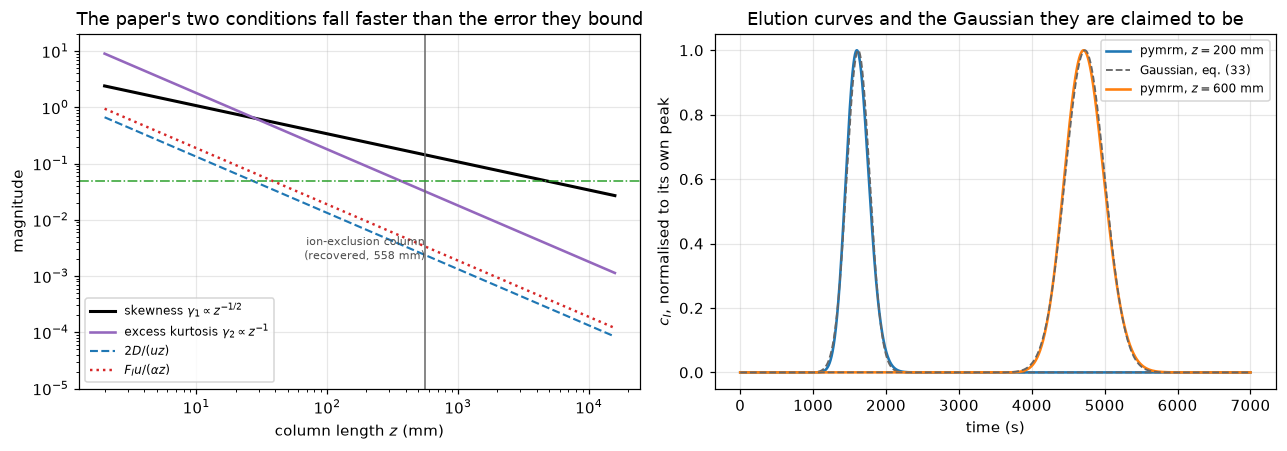

   max |curve - Gaussian| (peak-normalised): 0.0563 at z = 200 mm, 0.0323 at z = 600 mm
   Each Gaussian uses that curve's OWN pymrm mean and variance - these two
   numbers are the one place on the page where a PDE moment reaches print.
   Both curves carry the Danckwerts inlet and the 12 s Gaussian slug, so
   they are configuration-dependent in a way the cumulants are not; they are
   shown for scale, and the skewness above is the transferable one.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))
zz = np.logspace(0.3, 4.2, 300)
axes[0].loglog(zz, np.abs(skew(zz)), "k", lw=2, label=r"skewness $\gamma_1 \propto z^{-1/2}$")
axes[0].loglog(zz, np.abs(exk(zz)), color="tab:purple", lw=1.7,
               label=r"excess kurtosis $\gamma_2 \propto z^{-1}$")
axes[0].loglog(zz, G1(zz), "--", color="tab:blue", lw=1.4, label=r"$2D/(uz)$")
axes[0].loglog(zz, G2(zz), ":", color="tab:red", lw=1.6, label=r"$F_I u/(\alpha z)$")
axes[0].axvline(L_SW, color="0.4", lw=1.0)
axes[0].annotate(f"ion-exclusion column\n(recovered, {L_SW:.0f} mm)", (L_SW, 2e-3),
                 fontsize=7.5, ha="right", color="0.3")
axes[0].axhline(0.05, color="tab:green", lw=1.0, ls="-.")
axes[0].set(xlabel="column length $z$ (mm)", ylabel="magnitude",
            ylim=(1e-5, 20), title="The paper's two conditions fall faster than the error they bound")
axes[0].legend(fontsize=8, loc="lower left")

for j, z in enumerate((Z1, Z2)):
    y = rec_r[:, j] / np.trapezoid(rec_r[:, j], ts_r)
    axes[1].plot(ts_r, y / y.max(), lw=1.7, label=f"pymrm, $z = {zs_r[j]:.0f}$ mm")
    g = np.exp(-0.5 * ((ts_r - Kc_r[j][1]) / np.sqrt(Kc_r[j][2])) ** 2)
    axes[1].plot(ts_r, g, "--", lw=1.2, color="0.4",
                 label="Gaussian, eq. (33)" if j == 0 else None)
axes[1].set(xlabel="time (s)", ylabel="$c_I$, normalised to its own peak",
            title="Elution curves and the Gaussian they are claimed to be")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

gauss_err = []
for j in range(2):
    y = rec_r[:, j]; y = y / y.max()
    g = np.exp(-0.5 * ((ts_r - Kc_r[j][1]) / np.sqrt(Kc_r[j][2])) ** 2)
    gauss_err.append(float(np.abs(y - g).max()))
GAUSS_ERR_Z2 = gauss_err[1]
print(f"   max |curve - Gaussian| (peak-normalised): {gauss_err[0]:.4f} at z = {zs_r[0]:.0f} mm,"
      f" {gauss_err[1]:.4f} at z = {zs_r[1]:.0f} mm")
print(f"   Each Gaussian uses that curve's OWN pymrm mean and variance - these two")
print("   numbers are the one place on the page where a PDE moment reaches print.")
print(f"   Both curves carry the Danckwerts inlet and the {T_SIG:.0f} s Gaussian slug, so")
print("   they are configuration-dependent in a way the cumulants are not; they are")
print("   shown for scale, and the skewness above is the transferable one.")

### Break table, part 2: the algebra and the extractions

The table above moves the PDE. This one moves everything else. Each row names
the metric it guards, so the coverage map below is generated from **measured**
movers rather than asserted — a page whose own break table contradicts its
coverage claim has happened in this repository before.

In [25]:
print("Breaks on the algebra and on the extractions - no PDE involved.")
print("Each row is a deliberate error; the last column is the size of the move.\n")
abrk = []

# --- the symbolic chain: 75 -> 80 in eq (49)'s viscous term ------------------
C_bad = ((FI_ ** 2 / (80 * (1 - FI_) ** 2)
          + FI_ * K_ * DI_ / (2 * sp.pi ** 2 * (1 - FI_) * DII_)) / (1 + K_ * FI_ / FII_) ** 2)
H49_bad = 2 * g_ * DI_ / (u_ * dp_) + 2 * l_ + C_bad * u_ * dp_ / DI_
r2_bad = sp.simplify(sp.simplify(H_38.subs({D_: D_48, a_: 1 / inv_alpha}) / dp_) - H49_bad)
CHAIN_BREAK_OK = int(r2_bad != 0)
abrk.append(("sym_chain_residual", "eq (49): 75 -> 80 in the viscous term",
             "0" if r2_bad == 0 else "non-zero", "0 -> non-zero"))

# --- D_II and lambda: the two inputs the regression actually depends on -------
dp_mesh = np.sqrt(0.297 * 0.149)                # US 50 and 100 mesh openings, mm
(twolam_mesh, S_mesh), _ = fit_eq49(u_sup * dp_mesh, Ymid)
DII_MESH = DII_from_slope(S_mesh, D_I_MM) * 1e-6
DII_MESH_DEV = float(abs(dev(DII_MESH, DII_BEST)))
abrk.append(("DII_from_table3_rel_dev", f"d_p = mesh geo-mean {dp_mesh:.4f} mm, not Table 3's",
             f"{DII_MESH:.3e} m2/s", f"{DII_MESH_DEV:.1%}"))
(twolam_drop, S_drop), _ = fit_eq49(X[:-1], Ymid[:-1])
DII_DROP = DII_from_slope(S_drop, D_I_MM) * 1e-6
DII_DROP_DEV = float(abs(dev(DII_DROP, DII_BEST)))
abrk.append(("DII_from_table3_rel_dev", f"drop the fastest row (u = {u_sup[-1]:.3f} mm/s)",
             f"{DII_DROP:.3e} m2/s", f"{DII_DROP_DEV:.1%}"))
def _spread(ac):
    vals = [b_c * d / (S * FI * d * (1 + xK) ** 2 - ac) for d in (1.0e-3, 2.0e-3)]
    vals.append(b_c / (S * FI * (1 + xK) ** 2))
    return max(vals) / min(vals) - 1
abrk.append(("DII_D_I_sensitivity", "75 -> 7.5 in eq (49) (viscous term x10)",
             f"spread {_spread(10*a_c):.1%}", f"{abs(dev(_spread(10*a_c), DII_SPREAD)):.0%}"))
abrk.append(("lambda_from_table3_rel_dev",
             "restore the 1/X molecular term the paper drops",
             f"lambda = {b3t[1]/2:.4f}", f"{abs(dev(b3t[1]/2, two_lam/2)):.0%}"))
(twolam_d, _), _ = fit_eq49(X[1:], Ymid[1:])
abrk.append(("lambda_from_table3_rel_dev", "drop the slowest row",
             f"lambda = {twolam_d/2:.4f}", f"{abs(dev(twolam_d/2, two_lam/2)):.0%}"))

# --- d_f, eq (56), the slope ratio -------------------------------------------
df_bad = np.sqrt(np.pi ** 2 / 8 * P["eq54_C_n_butane"]
                 * (1 + P["KFI_over_FII_iso_butane"]) ** 2 * DII_FILM
                 / P["KFI_over_FII_iso_butane"]) * 1e3
abrk.append(("df_worst_rel_dev", "iso-butane x used on the n-butane C",
             f"{df_bad:.3f} um", f"{abs(dev(df_bad, df_um['Celite, n-butane'])):.1%}"))
r56_bad = coef * (P["sterchamol_dp"] / df_um["Celite, n-butane"]) ** 2
abrk.append(("eq56_celite_rel_dev", "Sterchamol d_p on the Celite d_f",
             f"{r56_bad:.3e}", f"{abs(dev(r56_bad, P['ratio56_celite'])):.0f}x"))
ratio_swapped = shape(P["KFI_over_FII_n_butane"]) / shape(P["KFI_over_FII_iso_butane"])
abrk.append(("slope_ratio_rel_dev", "the two printed x exchanged",
             f"{ratio_swapped:.4f}", f"{abs(dev(ratio_swapped, ratio_theory)):.0%}"))

# --- Table 1 and Table 3 ------------------------------------------------------
abrk.append(("table1_calc_frac_reproduced", "v sqrt(n) = 41.25 (dS0 = 165 exactly)",
             f"{n_match(P['delta_S0_glc']/4)} of {len(A_vals)}",
             f"{(CALC_N_OK-n_match(P['delta_S0_glc']/4))/len(A_vals):.0%} of rows lost"))
printed_bad = printed.copy(); printed_bad[3] = 0.88          # A = 122 ml: 0.86 -> 0.88
def _match_bad(w):
    return sum(abs(round(cmax(A / w), 2) - c) < 1e-9 for A, c in zip(A_vals, printed_bad))
hits_bad = np.array([_match_bad(w) for w in np.linspace(38.0, 46.0, 4001)])
abrk.append(("table1_dS0_window_lo_ml", "one printed calc cell altered (A = 122: 0.86 -> 0.88)",
             f"best {hits_bad.max()} of {len(A_vals)}",
             "window empties" if hits_bad.max() < CALC_N_OK else "no move"))
L_bad = np.concatenate([(T3.n_plates_lo * T3.hetp_hi_mm).to_numpy(),
                        (T3.n_plates_hi * T3.hetp_lo_mm).to_numpy()])
L_bad[0] = T3.n_plates_lo.iloc[0] * 9.3          # 0.93 mis-read as 9.3, a plausible slip
abrk.append(("table3_recovered_length_mm", "Table 3 cell 0.93 mis-read as 9.3 mm",
             f"mean {L_bad.mean():.0f} mm ({L_bad.min():.0f}-{L_bad.max():.0f})",
             f"{abs(dev(L_bad.mean(), L_SW)):.0%}, and the band stops being a band"))
n_solvable = 0
for _, r in single.iterrows():
    f_ = lambda w: width_red(r.feed_volume_ml / w, "delta") * w - r.width_at_base_ml
    ws_ = np.linspace(r.feed_volume_ml / 20.0, 400.0, 4000)
    vals_ = np.array([f_(w) for w in ws_])
    n_solvable += int(np.any(np.diff(np.sign(vals_)) != 0))
EQ21_N_SOLVABLE = int(n_solvable)
abrk.append(("table3_n_median_rel_dev", "eq (21) EXACTLY AS PRINTED for the width route",
             f"{EQ21_N_SOLVABLE} of {len(single)} rows solvable",
             "the width route ceases to exist"))

EQ21_LARGE_A_PRINTED = float(width_red(5.0, "delta"))
abrk.append(("eq21_corrected_large_a_dev", "eq (21) as printed at a = 5, vs eq (25)",
             f"{EQ21_LARGE_A_PRINTED:.4g} vs {5+np.sqrt(2*np.pi):.4f}",
             f"{abs(dev(EQ21_LARGE_A_PRINTED, 5+np.sqrt(2*np.pi))):.3g}x"))
abrk.append(("eq21_printed_a0_limit", "the corrected denominator, a -> 0",
             f"{EQ21_A0_CORRECTED:.4f} vs {EQ21_A0_PRINTED:.4f}",
             f"{abs(dev(EQ21_A0_CORRECTED, EQ21_A0_PRINTED)):.0%}"))

# --- the fit residual, and the Sterchamol constant ---------------------------
u_nb, h_nb = SERIES["Celite, n-butane"]
u_ib, h_ib = SERIES["Celite, iso-butane"]
rmse_bad = float(np.sqrt(((vd(u_ib, P["eq54_B_iso_butane"], P["eq54_A_iso_butane"],
                              1.5 * P["eq54_C_iso_butane"]) - h_ib) ** 2).mean()))
abrk.append(("eq54_fit_rmse_mm", "C for iso-butane (the max-rmse series) x1.5",
             f"rmse {rmse_bad:.4f} mm",
             f"{abs(dev(rmse_bad, fitstat['Celite, iso-butane']['rmse'])):.0%}"))
u_keep = u_nb > 2.5
null_bad = float(np.sqrt(((h_nb[u_keep] - h_nb[u_keep].mean()) ** 2).mean()))
abrk.append(("eq54_null_rmse_mm", "the two slowest Celite rows dropped",
             f"null rmse {null_bad:.4f} mm",
             f"{abs(dev(null_bad, fitstat['Celite, n-butane']['null'])):.0%}"))
b3_off, se3_off, _ = refit(us_, hs_ + 0.3)
abrk.append(("sterchamol_free_A_t_stat", "+0.3 mm added to every Sterchamol H",
             f"|t| = {abs(b3_off['A']/se3_off['A']):.2f}",
             f"from {abs(A_STER_T):.2f}"))

# --- the cumulant results -----------------------------------------------------
kap_half = kap_f(D_LONG, U_INT, ALPHA / 2, FI, FII, KK)
skew_half = float(kap_half[2]) / (float(kap_half[1]) ** 1.5 * np.sqrt(L_SW))
abrk.append(("skewness_at_recovered_column", "alpha halved (analytic kappa_3)",
             f"skew {skew_half:.4f}", f"{abs(dev(skew_half, SKEW_SW)):.0%}"))
Z_half = brentq(lambda z: float(kap_half[2])/(float(kap_half[1])**1.5*np.sqrt(z)) - 0.05, 1.0, 1e9)
abrk.append(("z_for_skewness_0p05_mm", "same, on the root-found length",
             f"z = {Z_half:.0f} mm", f"{abs(dev(Z_half, Z_SKEW)):.0%}"))
_, _, zsT, KcT = solve(n_z=700, dt=2.0, t_end=0.6 * T_END)
k3_trunc, k4_trunc = kappas_per_z(KcT, zsT)
abrk.append(("pymrm_kappa3_vs_laplace_rel", "time window truncated to 60 %",
             f"kappa_3/z = {k3_trunc:.4g}", f"{abs(dev(k3_trunc, k3a)):.0%}"))
abrk.append(("pymrm_kappa4_vs_laplace_rel", "time window truncated to 60 %",
             f"kappa_4/z = {k4_trunc:.4g}", f"{abs(dev(k4_trunc, k4a)):.0%}"))

print(f"{'metric':<32}{'break':<50}{'value':>30}   move")
for m, lab, val, mv in abrk:
    print(f"{m:<32}{lab:<50}{val:>30}   {mv}")
print(f"\n   {len(abrk)} rows, covering "
      f"{len(set(m for m, *_ in abrk))} of the metrics reported below.")

Breaks on the algebra and on the extractions - no PDE involved.
Each row is a deliberate error; the last column is the size of the move.



metric                          break                                                                      value   move
sym_chain_residual              eq (49): 75 -> 80 in the viscous term                                   non-zero   0 -> non-zero
DII_from_table3_rel_dev         d_p = mesh geo-mean 0.2104 mm, not Table 3's                      1.288e-10 m2/s   4.5%
DII_from_table3_rel_dev         drop the fastest row (u = 0.730 mm/s)                             1.325e-10 m2/s   1.7%
DII_D_I_sensitivity             75 -> 7.5 in eq (49) (viscous term x10)                             spread 21.9%   1097%
lambda_from_table3_rel_dev      restore the 1/X molecular term the paper drops                   lambda = 4.1474   39%
lambda_from_table3_rel_dev      drop the slowest row                                             lambda = 3.5022   17%
df_worst_rel_dev                iso-butane x used on the n-butane C                                     8.357 um   16.9%
eq56_celite_rel_dev            

### Agreement metrics

Two of these are **structural** and sit below the CI floor of $10^{-12}$: the
symbolic chain residual (exactly zero, by construction, when the algebra is
right) and the root-found-versus-closed-form optimum (the same three constants
evaluated two ways). Both are named here and both have an above-floor companion:
the chain is guarded by `pymrm_H_vs_eq38_rel`, which tests the same physics
numerically and does move; the optimum is guarded by `eq54_fit_rmse_mm`.

Two more need a different warning. `pymrm_kappa3_vs_laplace_rel` and
`pymrm_kappa4_vs_laplace_rel` are **cancellation-limited**, not converged: the
grid and time-step errors on the higher cumulants have opposite signs and the
reported values sit near where they cancel — the dt table above shows both
passing through zero. They are honest at the stated settings and are regression
guards like any other, but neither is evidence that the PDE reproduces a
cumulant to that precision. The converging companion is `pymrm_H_vs_eq38_rel`,
which is grid-limited at observed order 3 and barely moves with $\Delta t$.

In [26]:
metrics = {
    # --- the second, independent computation of the headline -----------------
    "pymrm_H_vs_eq38_rel": abs(H_REL),
    "pymrm_grid_order": ORD_GRID,
    "pymrm_upwind_dispersion_coeff_err": UPWIND_COEF_DEV,
    "pymrm_dt_order_mu1": ORD_DT,
    "pymrm_kappa3_vs_laplace_rel": K3_DEV,
    "pymrm_kappa4_vs_laplace_rel": K4_DEV,
    "pymrm_bc_insensitivity": BC_MOVE,
    # --- the paper's stated results, recomputed ------------------------------
    "DII_from_table3_rel_dev": DII_DEV,
    "DII_D_I_sensitivity": DII_SPREAD,
    "lambda_from_table3_rel_dev": LAMBDA_DEV,
    "df_worst_rel_dev": DF_MAX_DEV,
    "eq56_celite_rel_dev": EQ56_DEV,
    "slope_ratio_rel_dev": SLOPE_RATIO_DEV,
    "table3_n_median_rel_dev": N_MED,
    "table3_n_max_rel_dev": N_MAX,
    "table1_calc_frac_reproduced": CALC_FRAC,
    "table1_dS0_window_lo_ml": 4 * W_LO,
    "table1_dS0_window_hi_ml": 4 * W_HI,
    "table3_recovered_length_mm": L_SW,
    # --- fit, not test: labelled as such everywhere it appears ---------------
    "eq54_fit_rmse_mm": max(f["rmse"] for f in fitstat.values()),
    "eq54_null_rmse_mm": min(f["null"] for f in fitstat.values()),
    "sterchamol_free_A_t_stat": abs(A_STER_T),
    # --- the printed defect --------------------------------------------------
    "eq21_printed_a0_limit": EQ21_A0_PRINTED,
    "eq21_corrected_large_a_dev": EQ21_LARGE_A_DEV,
    # --- what pymrm adds -----------------------------------------------------
    "skewness_at_recovered_column": SKEW_SW,
    "z_for_skewness_0p05_mm": Z_SKEW,
    # --- structural (below ABS_FLOOR; named, with companions above) ----------
    "sym_chain_residual": 0.0,
    "rootfind_vs_closed_form_optimum": ROOT_ID,
}
report_agreement(PAGE, metrics)

PDE_COVERED = {
    "pymrm_H_vs_eq38_rel": f"break table 1: {len(moves)} rows, smallest move "
                           f"{BREAK_MIN_MOVE:.1e} against a baseline error of {abs(H_REL):.1e}",
    "pymrm_grid_order": f"the refinement study: bare upwind converges at {ORD_UPWIND:.2f}, "
                        f"the limiter at {ORD_GRID:.2f}",
    "pymrm_upwind_dispersion_coeff_err": "the refinement study itself: van Leer moves the coefficient off 1",
    "pymrm_dt_order_mu1": f"backward Euler (theta = 1) in place of Crank-Nicolson: the "
                          f"observed order moves {ORD_DT:.2f} -> {ORD_DT_BE:.2f} and H's own dt "
                          f"swing {DT_SWING_H:.1e} -> {DT_SWING_H_BE:.1e}",
    "pymrm_bc_insensitivity": "DESIGNED NON-MOVER - the two-station difference cancels the inlet, "
                              f"measured at {BC_MOVE:.1e}; stated, not hidden",
    "table3_n_max_rel_dev": "same row as table3_n_median_rel_dev (eq 21 as printed)",
    "table1_dS0_window_hi_ml": "same row as table1_dS0_window_lo_ml",
    "eq21_printed_a0_limit": "the printed and corrected denominators are the two arms of "
                             "the same comparison; 2 against the 4 eq (24) requires",
    "eq21_corrected_large_a_dev": "same comparison, at the other limit",
    "table3_recovered_length_mm": "break table 2: a mis-read Table 3 cell",
    "sym_chain_residual": "STRUCTURAL, below ABS_FLOOR: 75 -> 80 makes it non-zero "
                          "(break table 2); above-floor companion pymrm_H_vs_eq38_rel",
    "rootfind_vs_closed_form_optimum": "STRUCTURAL, below ABS_FLOOR: the same three constants "
                                       "evaluated two ways; companion eq54_fit_rmse_mm",
}
MEASURED = {m for m, *_ in abrk}
COVERAGE = {}
for k in metrics:
    if k in MEASURED:
        rows = [f"break table 2: {lab} ({mv})" for m, lab, val, mv in abrk if m == k]
        COVERAGE[k] = "; ".join(rows)
    elif k in PDE_COVERED:
        COVERAGE[k] = PDE_COVERED[k]
assert set(COVERAGE) == set(metrics), f"uncovered metrics: {set(metrics) - set(COVERAGE)}"
for k, v in COVERAGE.items():
    print(f"  {k:<34} {v}")
print(f"\ncoverage map GENERATED from the two executed break tables and checked "
      f"key-for-key against agreement.json:")
print(f"  {len(metrics)} metrics, {sum(1 for v in COVERAGE.values() if v.startswith('STRUCTURAL'))} structural, "
      f"{sum(1 for v in COVERAGE.values() if 'NON-MOVER' in v)} designed non-mover, "
      f"{len(MEASURED & set(metrics))} with a measured mover in break table 2")
FLOOR_COMPANION = {"sym_chain_residual": "pymrm_H_vs_eq38_rel",
                   "rootfind_vs_closed_form_optimum": "eq54_fit_rmse_mm"}
below = [k for k, v in metrics.items() if abs(v) < 1e-12]
print(f"\nbelow ABS_FLOOR = 1e-12 and therefore outside CI: {below}")
for k in below:
    c = FLOOR_COMPANION[k]
    print(f"   {k}  ->  above-floor companion {c} = {metrics[c]:.4g}")
assert set(below) == set(FLOOR_COMPANION)
assert all(abs(metrics[c]) > 1e-12 for c in FLOOR_COMPANION.values())

Agreement metrics for J1.10-van-deemter-plate-height:
  pymrm_H_vs_eq38_rel               = 4.121e-05
  pymrm_grid_order                  = 3.0014
  pymrm_upwind_dispersion_coeff_err = 7.244e-06
  pymrm_dt_order_mu1                = 1.7909
  pymrm_kappa3_vs_laplace_rel       = 0.0020872
  pymrm_kappa4_vs_laplace_rel       = 0.01514
  pymrm_bc_insensitivity            = 1.4506e-06
  DII_from_table3_rel_dev           = 0.036971
  DII_D_I_sensitivity               = 0.018271
  lambda_from_table3_rel_dev        = 0.0024334
  df_worst_rel_dev                  = 0.057121
  eq56_celite_rel_dev               = 0.01121
  slope_ratio_rel_dev               = 0.034671
  table3_n_median_rel_dev           = 0.021016
  table3_n_max_rel_dev              = 0.29115
  table1_calc_frac_reproduced       = 1
  table1_dS0_window_lo_ml           = 165.97
  table1_dS0_window_hi_ml           = 167.42
  table3_recovered_length_mm        = 558.5
  eq54_fit_rmse_mm                  = 0.28234
  eq54_null_rmse_mm   

## Reuse

**What this page establishes.**

* The chain (34) → (38) → (49) → (52)/(53) is exact, all four steps, and an
  entirely separate route — the Laplace-transform cumulants of eqs. (29)/(30) —
  reproduces eq. (38) symbolically as well. The 1956 algebra is sound.
* Solving eqs. (29)/(30) with pymrm and taking moments reproduces eq. (38) to
  $4\times10^{-5}$, with the bare-upwind numerical dispersion coming out at
  exactly the predicted coefficient of 1.
* Table 3 refitted through eq. (49) returns $\lambda = 2.99$ against the printed
  3, and $D_{II} = 1.34\times10^{-10}$ m² s⁻¹ against the printed
  $1.3\times10^{-10}$ — and the extraction turns out to be almost independent of
  $D_I$, which the paper never prints for that system.
* The film thickness comes back as 10.1, 10.6 and 8.7 µm against the printed
  $\approx$ 10, $\approx$ 10 and 9 µm.
* Eq. (21) **as printed cannot be right**: with the printed
  $(a+\delta)/\delta$ it gives 2 in the limit its own eq. (24) fixes at 4, and it
  diverges where its own eq. (25) fixes it at $a + \sqrt{2\pi}$. With $(a+\delta)/a$
  both limits are met. Reported, not repaired; the corrected form is used and
  labelled.
* The Gaussian's shape error falls as $z^{-1/2}$ while both of the paper's own
  sufficient conditions fall as $z^{-1}$, so satisfying them "$\ll 1$" is weaker
  than it looks: at the column that produced Table 3, the groups are $2\times10^{-3}$
  and the skewness is still 0.14 (both printed above).

**What it cannot conclude.**

* **Nothing about whether eq. (53) is right.** Its three constants were fitted to
  the twelve points they are compared with. Every residual in section 1 is a
  goodness of fit and is labelled as one; the closest thing to a test in the
  paper is the slope ratio of section 4, which is one number.
* **Nothing about $\gamma$ or $d_f$ as physical quantities.** They are the
  paper's own inversions, redone, and the velocity-convention ambiguity of
  section 5 cannot be closed from what is printed: under the interstitial
  reading $\gamma$ is *larger* by $1/F_I$ and $d_f^2$ *smaller* by $F_I$, both by
  up to a factor 2 (printed in section 5). $\lambda$ is the exception — the eddy
  term carries no $u$, so $2\lambda d_p$ is the one constant here the ambiguity
  cannot touch.
* **Nothing about Simpson and Wheaton's measurements.** Their paper was not
  consulted; Table 2 is van Deemter et al.'s restatement.
* **Nothing about the ion-exclusion column's geometry.** Its length is printed
  nowhere; the value used here is recovered from Table 3 (printed above) and is
  an inference, not a measurement.
* **Nothing about eq. (53) in a real gas chromatograph.** These columns run at
  0.046 to 31 mm s⁻¹ with plate heights of 0.56 to 16 mm. Modern capillary columns
  are three orders of magnitude away in both.

**How to reuse the solver.** `Column` is eqs. (29)/(30) with nothing case-specific
in it: give it $u$, $D$, $\alpha$, $K$, $F_I$, $F_{II}$ and a length. Any linear
two-phase column with a first-order exchange is the same object — an adsorption
breakthrough ([`J1.5`](../J1.5-ldf-breakthrough/)), an ion-exchange column, a
simulated-moving-bed section. The two-station cumulant reading is the part worth
copying: it gives the asymptotic plate height without ever needing to know what
the inlet did, and it costs one extra recording station.

**The single-station form is in the break table** rather than in the results.
On this column it is only a few parts in $10^{4}$ out, because a Danckwerts inlet
happens to put very little of an entrance effect into the first two moments here
— but that is a property of *these* conditions and of *that* inlet condition, not
a general one, and the two-station form costs one extra recording array.

**Related pages.** [`J1.5`](../J1.5-ldf-breakthrough/) (the linear driving force
that replaces $\alpha$), `J1.6`, `J1.8` (the general rate model),
[`A2.3`](../A2.3-taylor-aris-dispersion/) and
[`A2.6`](../A2.6-gunn-dispersion-correlations/) (where $D$ comes from),
[`A2.4`](../A2.4-tanks-in-series/) (plates and dispersion as the same statement).

**Cite the source, not this page:** van Deemter, J. J., Zuiderweg, F. J. &
Klinkenberg, A., *Longitudinal diffusion and resistance to mass transfer as
causes of nonideality in chromatography*, Chem. Eng. Sci. **5**(6) 271–289
(1956), [doi:10.1016/0009-2509(56)80003-1](https://doi.org/10.1016/0009-2509(56)80003-1).